In [20]:
import os
import warnings
from datetime import datetime

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from tabpfn import TabPFNRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="overflow encountered in expm1")
# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------
PROJECT_ROOT_DIR = os.getcwd()   # Notebook里用当前工作目录
os.environ["TABPFN_MODEL_CACHE_DIR"] = PROJECT_ROOT_DIR

IMAGE_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
MODEL_PATH = os.path.join(PROJECT_ROOT_DIR, "models")
DATA_PATH = os.path.join(PROJECT_ROOT_DIR, "dataset")

os.makedirs(IMAGE_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("PROJECT_ROOT_DIR =", PROJECT_ROOT_DIR)
print("TABPFN_MODEL_CACHE_DIR =", os.environ["TABPFN_MODEL_CACHE_DIR"])
print("CKPT exists =", os.path.exists(os.path.join(PROJECT_ROOT_DIR, "tabpfn-v2.5-regressor-v2.5_default.ckpt")))

PROJECT_ROOT_DIR = C:\NAS_new\NAS\博士后-浙大\课题\氧逸度\论文撰写\初稿\20260325\SA拟提交版本\Garnet-based-Oxybarometer\Code\Train
TABPFN_MODEL_CACHE_DIR = C:\NAS_new\NAS\博士后-浙大\课题\氧逸度\论文撰写\初稿\20260325\SA拟提交版本\Garnet-based-Oxybarometer\Code\Train
CKPT exists = True


In [2]:
# ==========================================================
# GLOBAL PLOT STYLE — SA-LIKE UNIFIED STYLE
# ==========================================================
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import MaxNLocator
# -----------------------------
# Unified labels
# -----------------------------
LITHOLOGY_1_LABEL = 1
LITHOLOGY_1_NAME = "Peridotitic"

LITHOLOGY_2_LABEL = 2
LITHOLOGY_2_NAME = "Basaltic"

COLOR_PERIDOTITIC = "#3D5A80"
COLOR_BASALTIC = "#D08C60"
COLOR_ID = "#4C72B0"
COLOR_PT_OOD = "#2CA02C"
COLOR_FEATURE_OOD = "#D62728"
COLOR_FEATURE_RANGE_OOD = "#8C564B"

def set_sa_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 10,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 10,
        "axes.linewidth": 1.1,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 4,
        "ytick.major.size": 4,

  
        "xtick.direction": "out",
        "ytick.direction": "out",


        "xtick.top": False,
        "ytick.right": False,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": 100,
        "savefig.dpi": 600,
    })

def beautify_axis(ax, spine_width=1.1):
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)


    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        width=1.2,
        length=4,
        bottom=True,
        top=False,
        left=True,
        right=False
    )

def get_lithology_colors():
    return {
        LITHOLOGY_1_LABEL: COLOR_PERIDOTITIC,
        LITHOLOGY_2_LABEL: COLOR_BASALTIC,
    }

def get_lithology_labels():
    return {
        LITHOLOGY_1_LABEL: LITHOLOGY_1_NAME,
        LITHOLOGY_2_LABEL: LITHOLOGY_2_NAME,
    }

def plot_reference_prediction_panel(
    y_ref,
    y_pred,
    lithology_code,
    xlabel,
    ylabel,
    save_png,
    save_pdf,
    title="Test set",
    metrics_text=None,
    figsize=(5, 5),
):
    set_sa_style()
    color_map = get_lithology_colors()
    label_map = get_lithology_labels()

    fig, ax = plt.subplots(figsize=figsize)

    for code in [LITHOLOGY_1_LABEL, LITHOLOGY_2_LABEL]:
        mask = lithology_code == code
        if np.sum(mask) > 0:
            ax.scatter(
                y_ref[mask],
                y_pred[mask],
                s=60,
                color=color_map[code],
                alpha=0.78,
                edgecolors="none",
                label=label_map[code],
            )

    min_val = min(np.min(y_ref), np.min(y_pred))
    max_val = max(np.max(y_ref), np.max(y_pred))
    pad = (max_val - min_val) * 0.04 if max_val > min_val else 0.5
    lo = min_val - pad
    hi = max_val + pad

    ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.1)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    locator = MaxNLocator(nbins=6)
    ax.xaxis.set_major_locator(locator)
    ax.yaxis.set_major_locator(locator)

    ax.set_title(title, pad=6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if metrics_text is not None:
        ax.text(
            0.05, 0.95,
            metrics_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2.5),
        )

    ax.legend(frameon=False, loc="lower right")
    beautify_axis(ax)

    plt.tight_layout()
    plt.savefig(save_png, bbox_inches="tight")
    plt.savefig(save_pdf, bbox_inches="tight")

def plot_delta_buffer_panel(
    x_ref,
    y_pred,
    lithology_code,
    delta_name,
    save_png,
    save_pdf,
    title="Test set",
    figsize=(5.2, 5.0),
):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    set_sa_style()
    color_map = get_lithology_colors()
    label_map = get_lithology_labels()

    rmse = np.sqrt(mean_squared_error(x_ref, y_pred))
    mae = mean_absolute_error(x_ref, y_pred)
    r2 = r2_score(x_ref, y_pred)

    fig, ax = plt.subplots(figsize=figsize)

    for code in [LITHOLOGY_1_LABEL, LITHOLOGY_2_LABEL]:
        mask = lithology_code == code
        if np.sum(mask) > 0:
            ax.scatter(
                x_ref[mask],
                y_pred[mask],
                s=60,
                color=color_map[code],
                alpha=0.78,
                edgecolors="none",
                label=label_map[code],
            )

    min_val = min(np.min(x_ref), np.min(y_pred))
    max_val = max(np.max(x_ref), np.max(y_pred))
    pad = 0.5
    lo = np.floor(min_val - pad)
    hi = np.ceil(max_val + pad)

    xline = np.array([lo, hi])
    ax.plot(xline, xline, "-", color="black", linewidth=1.1)
    ax.plot(xline, xline + 1, "--", color="gray", linewidth=1.0)
    ax.plot(xline, xline - 1, "--", color="gray", linewidth=1.0)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ticks = np.arange(lo, hi + 1, 1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, pad=6)
    ax.set_xlabel(f"Reference {delta_name}")
    ax.set_ylabel(f"Predicted {delta_name}")

    ax.text(
        0.05, 0.95,
        f"RMSE = {rmse:.3f}\nMAE = {mae:.3f}\nR² = {r2:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2.5),
    )

    ax.legend(frameon=False, loc="lower right")
    beautify_axis(ax)

    plt.tight_layout()
    plt.savefig(save_png, bbox_inches="tight")
    plt.savefig(save_pdf, bbox_inches="tight")
    plt.show()

    return rmse, mae, r2

In [3]:
# ----------------------------------------------------------
# Relative molecular masses of oxides (g/mol)
# ----------------------------------------------------------
molar_masses = {
    "SiO2": 60.08,
    "TiO2": 79.87,
    "Al2O3": 101.96,
    "FeO": 71.84,
    "MgO": 40.30,
    "CaO": 56.08,
    "Na2O": 61.98,
    "Cr2O3": 151.99,
    "MnO": 70.94,
}

# ----------------------------------------------------------
# Number of metal cations in each oxide
# ----------------------------------------------------------
cation_numbers = {
    "Si": 1,
    "Ti": 1,
    "Al": 2,
    "Fe": 1,
    "Mg": 1,
    "Ca": 1,
    "Na": 2,
    "Cr": 2,
    "Mn": 1,
}


def calculate_chemical_formula(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate garnet structural formula normalized to 12 oxygens.
    Input dataframe columns must be:
    Si_Grt, Ti_Grt, Al_Grt, Fe_Grt, Mg_Grt, Ca_Grt, Na_Grt, Cr_Grt, Mn_Grt
    """
    oxygen_atoms = 12
    results = []

    for _, row in df.iterrows():
        n_Si = row["Si_Grt"] / molar_masses["SiO2"]
        n_Ti = row["Ti_Grt"] / molar_masses["TiO2"]
        n_Al = row["Al_Grt"] / molar_masses["Al2O3"]
        n_Fe = row["Fe_Grt"] / molar_masses["FeO"]
        n_Mg = row["Mg_Grt"] / molar_masses["MgO"]
        n_Ca = row["Ca_Grt"] / molar_masses["CaO"]
        n_Na = row["Na_Grt"] / molar_masses["Na2O"]
        n_Cr = row["Cr_Grt"] / molar_masses["Cr2O3"]
        n_Mn = row["Mn_Grt"] / molar_masses["MnO"]

        total_oxygen = (
            n_Si * 2
            + n_Ti * 2
            + n_Al * 3
            + n_Fe
            + n_Mg
            + n_Ca
            + n_Na
            + n_Cr * 3
            + n_Mn
        )

        z = oxygen_atoms / total_oxygen

        ion_numbers = {
            "Si": n_Si * cation_numbers["Si"] * z,
            "Ti": n_Ti * cation_numbers["Ti"] * z,
            "Al": n_Al * cation_numbers["Al"] * z,
            "Fe": n_Fe * cation_numbers["Fe"] * z,
            "Mg": n_Mg * cation_numbers["Mg"] * z,
            "Ca": n_Ca * cation_numbers["Ca"] * z,
            "Na": n_Na * cation_numbers["Na"] * z,
            "Cr": n_Cr * cation_numbers["Cr"] * z,
            "Mn": n_Mn * cation_numbers["Mn"] * z,
        }

        results.append(
            {
                "Si": ion_numbers["Si"],
                "Ti": ion_numbers["Ti"],
                "Al": ion_numbers["Al"],
                "Cr": ion_numbers["Cr"],
                "Fe": ion_numbers["Fe"],
                "Mn": ion_numbers["Mn"],
                "Mg": ion_numbers["Mg"],
                "Ca": ion_numbers["Ca"],
                "Na": ion_numbers["Na"],
                "Correction_Factor_z": z,
            }
        )

    return pd.DataFrame(results)


def garnet_cation_filter(df_input: pd.DataFrame) -> pd.DataFrame:
    oxide_cols = [
        "Si_Grt",
        "Ti_Grt",
        "Al_Grt",
        "Cr_Grt",
        "Fe_Grt",
        "Mn_Grt",
        "Mg_Grt",
        "Ca_Grt",
        "Na_Grt",
    ]

    other_cols = [c for c in df_input.columns if c not in oxide_cols]

    formula_df = calculate_chemical_formula(df_input[oxide_cols])

    if "Correction_Factor_z" in formula_df.columns:
        formula_df = formula_df.drop(columns=["Correction_Factor_z"])

    formula_df.columns = [
        c if c.endswith("_Grt") else f"{c}_Grt"
        for c in formula_df.columns
    ]

    origin_df = df_input[oxide_cols].add_suffix("_origin")
    other_df = df_input[other_cols]

    df = pd.concat([formula_df, origin_df, other_df], axis=1)

    df = df.rename(
        columns={
            "Y value_P": "P",
            "Y value_T": "T",
            "Y value_fO2": "fO2",
        }
    )

    cation_cols = [
        "Si_Grt",
        "Ti_Grt",
        "Al_Grt",
        "Cr_Grt",
        "Fe_Grt",
        "Mn_Grt",
        "Mg_Grt",
        "Ca_Grt",
        "Na_Grt",
    ]

    df["cation_sum"] = df[cation_cols].sum(axis=1)

    original_count = len(df)
    df = df[(df["cation_sum"] >= 7.9) & (df["cation_sum"] <= 8.1)]
    removed_count = original_count - len(df)

    print(f"Removed samples (cation filter): {removed_count}")

    return df

In [4]:
def run_full_oxybarometer_pipeline(
    df_predict,
    prediction_name,
    df_P_T_train,
    df_fO2_train,
    BASE_FEATURES,
    P_model,
    T_model,
    fO2_model,
    calculate_iw,
    RESULT_DIR,
    RANDOM_STATE=42,
    FEATURE_OOD_K=3,
    FEATURE_OOD_PERCENTILE=99,
    PT_OOD_K=3,
    PT_OOD_PERCENTILE=95,
    PT_TRUE_COLUMNS=("P", "T"),
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.neighbors import NearestNeighbors

    print("====================================")
    print("Running full oxybarometer pipeline...")
    print("====================================\n")

    predict_df = df_predict.copy()

    # ==========================================================
    # 0. Build combined training set
    # ==========================================================
    train_full_df = pd.concat(
        [df_P_T_train, df_fO2_train],
        ignore_index=True
    )

    # ==========================================================
    # 1. Build feature range summary
    # ==========================================================
    feature_range_records = []

    for feature in BASE_FEATURES:
        feature_series = train_full_df[feature].dropna()

        q01 = feature_series.quantile(0.01)
        q99 = feature_series.quantile(0.99)
        fmin = feature_series.min()
        fmax = feature_series.max()

        feature_range_records.append({
            "feature": feature,
            "q01": q01,
            "q99": q99,
            "min": fmin,
            "max": fmax,
        })

    feature_range_df = pd.DataFrame(feature_range_records)

    print("Feature range summary from combined training set:")
    print(feature_range_df.to_string(index=False))
    print()

    # ==========================================================
    # 2. Feature-wise range screening
    # ==========================================================
    print("Running feature-wise range screening (1st–99th percentile)...")

    feature_range_masks = []

    for _, row in feature_range_df.iterrows():
        feature = row["feature"]
        q01 = row["q01"]
        q99 = row["q99"]

        out_of_range_mask = (
            (predict_df[feature] < q01) |
            (predict_df[feature] > q99)
        )

        predict_df[f"{feature}_out_of_range"] = out_of_range_mask
        feature_range_masks.append(out_of_range_mask.to_numpy())

    if len(feature_range_masks) > 0:
        feature_range_ood_mask = np.any(
            np.column_stack(feature_range_masks),
            axis=1
        )
    else:
        feature_range_ood_mask = np.zeros(len(predict_df), dtype=bool)

    predict_df["is_feature_range_OOD"] = feature_range_ood_mask
    predict_df["feature_range_OOD_level"] = "In-Range"
    predict_df.loc[
        feature_range_ood_mask, "feature_range_OOD_level"
    ] = "Out-of-Range"

    print(
        "Feature-wise range OOD ratio:",
        round(np.mean(feature_range_ood_mask) * 100, 2),
        "%\n"
    )

    # ==========================================================
    # 3. Feature-space OOD detection
    # ==========================================================
    print("Running feature-space OOD detection...")

    X_train = train_full_df[BASE_FEATURES].copy()
    X_predict = predict_df[BASE_FEATURES].copy()

    feature_scaler = StandardScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train)
    X_predict_scaled = feature_scaler.transform(X_predict)

    if FEATURE_OOD_K < 1:
        raise ValueError("FEATURE_OOD_K must be >= 1")

    if len(X_train_scaled) <= FEATURE_OOD_K:
        raise ValueError(
            f"FEATURE_OOD_K={FEATURE_OOD_K} is too large for the feature training set "
            f"({len(X_train_scaled)} samples). Please use a smaller FEATURE_OOD_K."
        )

    feature_nn = NearestNeighbors(n_neighbors=FEATURE_OOD_K)
    feature_nn.fit(X_train_scaled)

    feature_distances, _ = feature_nn.kneighbors(X_predict_scaled)
    feature_distances = feature_distances.mean(axis=1)

    feature_train_nn = NearestNeighbors(n_neighbors=FEATURE_OOD_K + 1)
    feature_train_nn.fit(X_train_scaled)

    feature_train_distances, _ = feature_train_nn.kneighbors(X_train_scaled)
    feature_train_knn_dist = feature_train_distances[:, 1:].mean(axis=1)

    feature_threshold_ood = np.percentile(
        feature_train_knn_dist,
        FEATURE_OOD_PERCENTILE
    )
    feature_ood_mask = feature_distances > feature_threshold_ood

    predict_df["feature_OOD_distance"] = feature_distances
    predict_df["feature_OOD_level"] = "In-Distribution"
    predict_df.loc[feature_ood_mask, "feature_OOD_level"] = "OOD"
    predict_df["is_feature_OOD"] = feature_ood_mask

    print(f"Feature-space OOD k: {FEATURE_OOD_K}")
    print(
        f"Feature-space OOD threshold ({FEATURE_OOD_PERCENTILE}th percentile):",
        round(feature_threshold_ood, 4)
    )
    print(
        "Feature-space OOD ratio:",
        round(np.mean(feature_ood_mask) * 100, 2),
        "%\n"
    )

    # ==========================================================
    # 4. P–T prediction
    # ==========================================================
    print("Predicting P and T...")

    X_pred = predict_df[BASE_FEATURES].copy()

    predict_df["P_pred"] = P_model.predict(X_pred)
    predict_df["T_pred"] = T_model.predict(X_pred)

    print("Mean P:", round(predict_df["P_pred"].mean(), 3))
    print("Mean T:", round(predict_df["T_pred"].mean(), 3), "\n")

    # ==========================================================
    # 5. P–T OOD detection
    # ==========================================================
    print("Running P–T OOD detection on the combined training set...")

    p_col, t_col = PT_TRUE_COLUMNS

    pt_train_sources = []

    if p_col in df_P_T_train.columns and t_col in df_P_T_train.columns:
        pt_train_sources.append(df_P_T_train[[p_col, t_col]].copy())

    if p_col in df_fO2_train.columns and t_col in df_fO2_train.columns:
        pt_train_sources.append(df_fO2_train[[p_col, t_col]].copy())

    if len(pt_train_sources) == 0:
        raise KeyError(
            f"Training P–T columns {PT_TRUE_COLUMNS} were not found in either "
            "df_P_T_train or df_fO2_train. Please set PT_TRUE_COLUMNS correctly."
        )

    PT_train_df = pd.concat(pt_train_sources, ignore_index=True).dropna().copy()

    if len(PT_train_df) == 0:
        raise ValueError(
            "No valid P–T training rows were found after combining the training datasets."
        )

    PT_train = PT_train_df[[p_col, t_col]].to_numpy()
    PT_predict = predict_df[["P_pred", "T_pred"]].to_numpy()

    pt_scaler = StandardScaler()
    PT_train_scaled = pt_scaler.fit_transform(PT_train)
    PT_predict_scaled = pt_scaler.transform(PT_predict)

    if PT_OOD_K < 1:
        raise ValueError("PT_OOD_K must be >= 1")

    if len(PT_train_scaled) <= PT_OOD_K:
        raise ValueError(
            f"PT_OOD_K={PT_OOD_K} is too large for the combined P–T training set "
            f"({len(PT_train_scaled)} samples). Please use a smaller PT_OOD_K."
        )

    pt_nn = NearestNeighbors(n_neighbors=PT_OOD_K)
    pt_nn.fit(PT_train_scaled)

    pt_distances, _ = pt_nn.kneighbors(PT_predict_scaled)
    pt_distances = pt_distances.mean(axis=1)

    pt_train_nn = NearestNeighbors(n_neighbors=PT_OOD_K + 1)
    pt_train_nn.fit(PT_train_scaled)

    pt_train_distances, _ = pt_train_nn.kneighbors(PT_train_scaled)
    pt_train_knn_dist = pt_train_distances[:, 1:].mean(axis=1)

    pt_threshold_ood = np.percentile(
        pt_train_knn_dist,
        PT_OOD_PERCENTILE
    )
    pt_ood_mask = pt_distances > pt_threshold_ood

    predict_df["PT_OOD_distance"] = pt_distances
    predict_df["PT_OOD_level"] = "In-Distribution"
    predict_df.loc[pt_ood_mask, "PT_OOD_level"] = "OOD"
    predict_df["is_PT_OOD"] = pt_ood_mask

    print(f"P–T OOD k: {PT_OOD_K}")
    print(
        f"P–T OOD threshold ({PT_OOD_PERCENTILE}th percentile):",
        round(pt_threshold_ood, 4)
    )
    print(
        "P–T OOD ratio:",
        round(np.mean(pt_ood_mask) * 100, 2),
        "%\n"
    )

    # ==========================================================
    # 6. IW calculation
    # ==========================================================
    use_iw_feature = False
    try:
        n_expected_with_iw = len(BASE_FEATURES) + 1
        if hasattr(fO2_model, "n_features_in_"):
            use_iw_feature = (fO2_model.n_features_in_ == n_expected_with_iw)
    except Exception:
        use_iw_feature = False

    predict_df["IW_pred"] = calculate_iw(
        predict_df["P_pred"],
        predict_df["T_pred"]
    )

    print("Mean IW:", round(predict_df["IW_pred"].mean(), 3), "\n")

    # ==========================================================
    # 7. fO2 prediction
    # ==========================================================
    if use_iw_feature:
        fO2_features = BASE_FEATURES + ["IW_pred"]
    else:
        fO2_features = BASE_FEATURES

    predict_df["logfO2_pred"] = fO2_model.predict(
        predict_df[fO2_features]
    )

    predict_df["dIW_pred"] = (
        predict_df["logfO2_pred"] - predict_df["IW_pred"]
    )

    print("Mean logfO2:", round(predict_df["logfO2_pred"].mean(), 3))
    print("Mean ΔIW:", round(predict_df["dIW_pred"].mean(), 3), "\n")

    # ==========================================================
    # 8. Final flag
    # ==========================================================
    predict_df["distribution_flag"] = "In-Distribution"

    predict_df.loc[
        predict_df["is_PT_OOD"],
        "distribution_flag"
    ] = "P-T OOD"

    predict_df.loc[
        predict_df["is_feature_OOD"],
        "distribution_flag"
    ] = "Feature OOD"

    predict_df.loc[
        predict_df["is_feature_range_OOD"],
        "distribution_flag"
    ] = "Feature range OOD"

    # ==========================================================
    # 9. PCA visualization
    # ==========================================================
    print("Running PCA visualization at the final step...")

    set_sa_style()

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_predict_pca = pca.transform(X_predict_scaled)

    pc1_var = pca.explained_variance_ratio_[0] * 100
    pc2_var = pca.explained_variance_ratio_[1] * 100

    color_map = {
        "In-Distribution": COLOR_ID,
        "P-T OOD": COLOR_PT_OOD,
        "Feature OOD": COLOR_FEATURE_OOD,
        "Feature range OOD": COLOR_FEATURE_RANGE_OOD,
    }

    fig, ax = plt.subplots(figsize=(6.0, 5.0))

    ax.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        alpha=0.55,
        color="#9A9A9A",
        s=22,
        edgecolors="none",
        label="Training set"
    )

    for category in [
        "In-Distribution",
        "P-T OOD",
        "Feature OOD",
        "Feature range OOD",
    ]:
        mask = predict_df["distribution_flag"] == category
        if np.any(mask):
            ax.scatter(
                X_predict_pca[mask, 0],
                X_predict_pca[mask, 1],
                alpha=0.90,
                color=color_map[category],
                s=36,
                edgecolors="black" if category != "In-Distribution" else "none",
                linewidths=0.35 if category != "In-Distribution" else 0,
                label=category,
            )

    ax.set_xlabel(f"PC1 ({pc1_var:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2_var:.1f}%)")
    ax.set_title("PCA of feature space", pad=6)

    beautify_axis(ax)
    ax.legend(frameon=False, loc="best")

    plt.tight_layout()

    pca_png = os.path.join(IMAGE_PATH, f"{prediction_name}_PCA.png")
    pca_pdf = os.path.join(IMAGE_PATH, f"{prediction_name}_PCA.pdf")
    plt.savefig(pca_png, bbox_inches="tight")
    plt.savefig(pca_pdf, bbox_inches="tight")
    plt.show()

    # ==========================================================
    # 10. Diagnostic plots
    # ==========================================================
    set_sa_style()

    fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9))
    point_colors = predict_df["distribution_flag"].map(color_map)

    axes[0].scatter(
        predict_df["P_pred"],
        predict_df["T_pred"],
        c=point_colors,
        alpha=0.78,
        s=24,
        edgecolors="none"
    )
    axes[0].set_xlabel("Predicted Pressure")
    axes[0].set_ylabel("Predicted Temperature")
    axes[0].set_title("Pressure–Temperature")

    axes[1].scatter(
        predict_df["IW_pred"],
        predict_df["logfO2_pred"],
        c=point_colors,
        alpha=0.78,
        s=24,
        edgecolors="none"
    )
    line_min = min(predict_df["IW_pred"].min(), predict_df["logfO2_pred"].min())
    line_max = max(predict_df["IW_pred"].max(), predict_df["logfO2_pred"].max())
    axes[1].plot(
        [line_min, line_max],
        [line_min, line_max],
        "--",
        color="gray",
        linewidth=1.0
    )
    axes[1].set_xlabel(r"Predicted logfO$_2$ (IW)")
    axes[1].set_ylabel(r"Predicted logfO$_2$")
    axes[1].set_title(r"logfO$_2$ vs IW")

    axes[2].hist(
        predict_df["dIW_pred"],
        bins=30,
        edgecolor="black",
        linewidth=0.5
    )
    axes[2].set_xlabel(r"Predicted $\Delta$IW")
    axes[2].set_ylabel("Count")
    axes[2].set_title(r"$\Delta$IW distribution")

    for ax in axes:
        beautify_axis(ax)

    plt.tight_layout()
    diag_png = os.path.join(IMAGE_PATH, f"{prediction_name}_diagnostic.png")
    diag_pdf = os.path.join(IMAGE_PATH, f"{prediction_name}_diagnostic.pdf")
    plt.savefig(diag_png, bbox_inches="tight")
    plt.savefig(diag_pdf, bbox_inches="tight")
    plt.show()

    # ==========================================================
    # 11. Export results
    # ==========================================================
    optional_columns = []
    for col in ["type", "dFMQ", "dIW", "logfO2"]:
        if col in predict_df.columns:
            optional_columns.append(col)

    feature_range_columns = [
        f"{feature}_out_of_range" for feature in BASE_FEATURES
    ]

    output_columns = (
        BASE_FEATURES
        + optional_columns
        + [
            "is_feature_range_OOD",
            "feature_range_OOD_level",
        ]
        + feature_range_columns
        + [
            "P_pred",
            "T_pred",
            "IW_pred",
            "logfO2_pred",
            "dIW_pred",
            "feature_OOD_distance",
            "feature_OOD_level",
            "is_feature_OOD",
            "PT_OOD_distance",
            "PT_OOD_level",
            "is_PT_OOD",
            "distribution_flag",
        ]
    )

    output_df = predict_df[output_columns]

    output_path = os.path.join(
        RESULT_DIR,
        f"{prediction_name}_oxybarometer_predictions.xlsx"
    )
    output_df.to_excel(output_path, index=False)

    feature_range_path = os.path.join(
        RESULT_DIR,
        f"{prediction_name}_feature_range_summary.xlsx"
    )
    feature_range_df.to_excel(feature_range_path, index=False)

    print("Saved prediction results to:", output_path)
    print("Saved feature range summary to:", feature_range_path)
    print("====================================\n")

    return predict_df, feature_range_df

In [5]:
# ----------------------------------------------------------
# Read Excel files
# ----------------------------------------------------------
data1 = os.path.join(DATA_PATH, "df_P_T_train.xlsx")
data2 = os.path.join(DATA_PATH, "df_P_T_test.xlsx")
data3 = os.path.join(DATA_PATH, "df_fO2_train.xlsx")
data4 = os.path.join(DATA_PATH, "df_fO2_test.xlsx")
data5 = os.path.join(DATA_PATH, "predicted-Mantle.xlsx")
data6 = os.path.join(DATA_PATH, "predicted-Diamond.xlsx")

df_P_T_train_ = pd.read_excel(data1, engine="openpyxl")
df_P_T_test_ = pd.read_excel(data2, engine="openpyxl")
df_fO2_train_ = pd.read_excel(data3, engine="openpyxl")
df_fO2_test_ = pd.read_excel(data4, engine="openpyxl")
df_predict1_ = pd.read_excel(data5, engine="openpyxl")
df_predict2_ = pd.read_excel(data6, engine="openpyxl")

for df_ in [
    df_P_T_train_,
    df_P_T_test_,
    df_fO2_train_,
    df_fO2_test_,
    df_predict1_,
    df_predict2_,
]:
    df_.fillna(0.00001, inplace=True)

print("ready")

ready


In [6]:
df_P_T_train = garnet_cation_filter(df_P_T_train_)
df_P_T_test = garnet_cation_filter(df_P_T_test_)

df_fO2_train = garnet_cation_filter(df_fO2_train_)
df_fO2_test = garnet_cation_filter(df_fO2_test_)

df_predict1 = garnet_cation_filter(df_predict1_)
df_predict2 = garnet_cation_filter(df_predict2_)

print("ready")

Removed samples (cation filter): 0
Removed samples (cation filter): 0
Removed samples (cation filter): 0
Removed samples (cation filter): 0
Removed samples (cation filter): 0
Removed samples (cation filter): 0
ready


In [34]:
print("Initializing FINAL oxybarometer pipeline...")

# ----------------------------------------------------------
# Random seed
# ----------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ----------------------------------------------------------
# Lithology
# ----------------------------------------------------------
LITHOLOGY_COLUMN = "cluster_label"

LITHOLOGY_1_LABEL = 1
LITHOLOGY_1_NAME = "Peridotitic"

LITHOLOGY_2_LABEL = 2
LITHOLOGY_2_NAME = "Basaltic"

# ----------------------------------------------------------
# Base features
# ----------------------------------------------------------
BASE_FEATURES = [
    "Si_Grt",
    "Ti_Grt",
    "Al_Grt",
    "Cr_Grt",
    "Fe_Grt",
    "Mg_Grt",
    "Ca_Grt",
    "Na_Grt",
]

print("Base feature count:", len(BASE_FEATURES))

# ----------------------------------------------------------
# Model selection
# ----------------------------------------------------------
MODEL_TYPE = "rf"  # "tabpfn" | "xgboost" | "rf"
print("Model type:", MODEL_TYPE)

# ----------------------------------------------------------
# Output directories
# ----------------------------------------------------------
MODEL_DIR = "models"
RESULT_DIR = "results"
SHAP_DIR = "shap_results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

print("Output directories ready.")


def calculate_iw(P, T):
    """
    Vectorized IW calculation
    P: GPa
    T: °C
    """
    P = np.asarray(P)
    T = np.asarray(T)
    T_kelvin = T + 273.15

    x0 = -18.64
    x1 = 0.04359
    x2 = -5.069e-6

    P_transition = x0 + x1 * T_kelvin + x2 * T_kelvin**2

    # fcc/bcc
    a = 6.844864 + 1.175691e-1 * P + 1.143873e-3 * P**2
    b = 5.791364e-4 - 2.891434e-4 * P - 2.737171e-7 * P**2
    c = (
        -7.971469e-5
        + 3.198005e-5 * P
        + 1.059554e-10 * P**3
        + 2.014461e-7 * np.sqrt(P)
    )
    d = -2.769002e4 + 5.285977e2 * P - 2.919275 * P**2

    iw_fcc = a + b * T_kelvin + c * T_kelvin * np.log(T_kelvin) + d / T_kelvin

    # hcp
    e = 8.463095 - 3.000307e-3 * P + 7.213445e-5 * P**2
    f = 1.148738e-3 - 9.352312e-5 * P + 5.161592e-7 * P**2
    g = (
        -7.448624e-4
        - 6.329325e-6 * P
        - 1.407339e-10 * P**3
        + 1.830014e-4 * np.sqrt(P)
    )
    h = -2.782082e4 + 5.285977e2 * P - 8.473231e-1 * P**2

    iw_hcp = e + f * T_kelvin + g * T_kelvin * np.log(T_kelvin) + h / T_kelvin

    iw = np.where(P <= P_transition, iw_fcc, iw_hcp)
    return iw


def fmq_hp2011(P, T):
    """
    FMQ using the Holland & Powell-style expression

    Parameters
    ----------
    P : float or array-like
        Pressure in GPa
    T : float or array-like
        Temperature in °C

    Returns
    -------
    logfO2 : float or ndarray
    """
    P = np.asarray(P)
    T = np.asarray(T)

    T_kelvin = T + 273.15
    P_kbar = P * 10.0  # 1 GPa = 10 kbar

    numerator = (
        -587474.0
        + 1584.427 * T_kelvin
        - 203.3164 * T_kelvin * np.log(T_kelvin)
        + 0.09271 * T_kelvin**2
        + 1810.0 * P_kbar
    )

    denominator = 8.3144 * T_kelvin * np.log(10.0)

    return numerator / denominator


def nno_campbell2009(P, T):
    """
    NNO buffer polynomial fit

    Polynomial form:
    log fO2 =
    (a0 + a1*P + a2*P^2 + a3*P^3 + a4*P^4)
    + (b0 + b1*P + b2*P^2 + b3*P^3) / T

    Parameters
    ----------
    P : float or array-like
        Pressure in GPa
    T : float or array-like
        Temperature in °C

    Returns
    -------
    logfO2 : float or ndarray
    """
    P = np.asarray(P)
    T = np.asarray(T)
    T_kelvin = T + 273.15

    a0 = 8.699000
    a1 = 0.016420
    a2 = -0.000276
    a3 = 2.6830e-06
    a4 = -1.0150e-08

    b0 = -24205.000000
    b1 = 444.730000
    b2 = -0.592880
    b3 = 0.001529

    return (
        a0
        + a1 * P
        + a2 * P**2
        + a3 * P**3
        + a4 * P**4
        + (b0 + b1 * P + b2 * P**2 + b3 * P**3) / T_kelvin
    )

def mh_schwab1981(P, T):
    """
    MH buffer (Schwab & Küstner 1981)

    log fO2 = 14.26 - 24949/T + 200P/T - 0.05P

    Parameters
    ----------
    P : float or array-like
        Pressure in GPa
    T : float or array-like
        Temperature in °C

    Returns
    -------
    logfO2 : float or ndarray
    """
    P = np.asarray(P)
    T = np.asarray(T)

    T_kelvin = T + 273.15

    return (
        14.26
        - 24949.0 / T_kelvin
        + (200.0 * P) / T_kelvin
        - 0.05 * P
    )

print("Thermodynamic IW function loaded.")
print("Thermodynamic FMQ function loaded.")
print("Thermodynamic NNO function loaded.")
print("Thermodynamic MH function loaded.")
print("SECTION 0 completed.\n")

Initializing FINAL oxybarometer pipeline...
Using device: cuda
Base feature count: 8
Model type: rf
Output directories ready.
Thermodynamic IW function loaded.
Thermodynamic FMQ function loaded.
Thermodynamic NNO function loaded.
Thermodynamic MH function loaded.
SECTION 0 completed.



In [35]:
def create_model(model_type, target):
    # ------------------------------------------------------
    # TabPFN
    # ------------------------------------------------------
    if model_type == "tabpfn":
        return TabPFNRegressor(model_path=os.path.join(PROJECT_ROOT_DIR, "tabpfn-v2.5-regressor-v2.5_default.ckpt"),device=DEVICE)

    # ------------------------------------------------------
    # XGBoost
    # ------------------------------------------------------
    if model_type == "xgboost":
        if target == "P":
            return XGBRegressor(
                n_estimators=3000,
                min_child_weight=2,
                max_depth=8,
                learning_rate=0.01,
                subsample=0.5,
                colsample_bytree=0.9,
                gamma=0,
                random_state=RANDOM_STATE,
                tree_method="hist",
                objective="reg:squarederror",
                n_jobs=1,
            )
        if target == "T":
            return XGBRegressor(
                n_estimators=3000,
                min_child_weight=3,
                max_depth=14,
                learning_rate=0.01,
                subsample=0.5,
                colsample_bytree=1,
                gamma=0.2,
                random_state=RANDOM_STATE,
                tree_method="hist",
                objective="reg:squarederror",
                n_jobs=1,
            )
        if target == "fO2":
            return XGBRegressor(
                n_estimators=2000,
                min_child_weight=4,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.6,
                gamma=0.2,
                random_state=RANDOM_STATE,
                tree_method="hist",
                objective="reg:squarederror",
                n_jobs=1,
            )
        raise ValueError("Unknown target for XGBoost")

    # ------------------------------------------------------
    # Random Forest
    # ------------------------------------------------------
    if model_type == "rf":
        if target == "P":
            return RandomForestRegressor(
                n_estimators=400,
                max_depth=15,
                min_samples_split=2,
                min_samples_leaf=1,
                max_features=0.6,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
        if target == "T":
            return RandomForestRegressor(
                n_estimators=2000,
                max_depth=23,
                min_samples_split=2,
                min_samples_leaf=1,
                max_features=0.6,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
        if target == "fO2":
            return RandomForestRegressor(
                n_estimators=1500,
                max_depth=13,
                min_samples_split=2,
                min_samples_leaf=1,
                max_features=0.8,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
        raise ValueError("Unknown target for RF")

    raise ValueError("Unknown MODEL_TYPE")


print("Model factory ready.")

Model factory ready.


In [36]:
def train_and_evaluate_pt_model(
    target_name,
    train_df,
    test_df,
    figure_prefix,
    result_filename,
):
    print(f"Preparing {target_name} model dataset...")

    X_train = train_df[BASE_FEATURES].copy()
    y_train = train_df[target_name].values

    X_test = test_df[BASE_FEATURES].copy()
    y_test = test_df[target_name].values

    stratify_labels = train_df[LITHOLOGY_COLUMN].values
    test_lithology_labels = test_df[LITHOLOGY_COLUMN].values

    print("Train size:", len(X_train))
    print("Test size :", len(X_test))

    # ------------------------------------------------------
    # 10-fold CV
    # ------------------------------------------------------
    print("\nStarting 10-fold CV...")

    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    rmse_list, mae_list, r2_list = [], [], []
    cv_lith_metrics = {
        LITHOLOGY_1_NAME: {"rmse": [], "mae": [], "r2": []},
        LITHOLOGY_2_NAME: {"rmse": [], "mae": [], "r2": []},
    }

    best_r2 = -np.inf
    best_fold_data = None
    best_fold_metrics = None

    for fold, (tr, val) in enumerate(skf.split(X_train, stratify_labels), start=1):
        X_tr, X_val = X_train.iloc[tr], X_train.iloc[val]
        y_tr, y_val = y_train[tr], y_train[val]
        lith_val = stratify_labels[val]

        model = create_model(MODEL_TYPE, target_name)
        model.fit(X_tr.values, y_tr)

        y_val_pred = model.predict(X_val.values)

        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        mae = mean_absolute_error(y_val, y_val_pred)
        r2 = r2_score(y_val, y_val_pred)

        rmse_list.append(rmse)
        mae_list.append(mae)
        r2_list.append(r2)

        print(f"Fold {fold}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

        for lith_label, lith_name in [
            (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
            (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
        ]:
            mask = lith_val == lith_label
            if np.sum(mask) >= 2:
                cv_lith_metrics[lith_name]["rmse"].append(
                    np.sqrt(mean_squared_error(y_val[mask], y_val_pred[mask]))
                )
                cv_lith_metrics[lith_name]["mae"].append(
                    mean_absolute_error(y_val[mask], y_val_pred[mask])
                )
                cv_lith_metrics[lith_name]["r2"].append(
                    r2_score(y_val[mask], y_val_pred[mask])
                )

        if r2 > best_r2:
            best_r2 = r2
            best_fold_data = (y_val, y_val_pred, lith_val)
            best_fold_metrics = (rmse, mae, r2)

    print("\nCV Results (Mean ± Std):")
    print(f"RMSE: {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")
    print(f"MAE : {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f}")
    print(f"R2  : {np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}")

    print("\nCV Results by Lithology (Mean ± Std):")
    for lith_name in [LITHOLOGY_1_NAME, LITHOLOGY_2_NAME]:
        print(f"\n{lith_name}:")
        print(
            f"  RMSE: {np.mean(cv_lith_metrics[lith_name]['rmse']):.4f} ± "
            f"{np.std(cv_lith_metrics[lith_name]['rmse']):.4f}"
        )
        print(
            f"  MAE : {np.mean(cv_lith_metrics[lith_name]['mae']):.4f} ± "
            f"{np.std(cv_lith_metrics[lith_name]['mae']):.4f}"
        )
        print(
            f"  R2  : {np.mean(cv_lith_metrics[lith_name]['r2']):.4f} ± "
            f"{np.std(cv_lith_metrics[lith_name]['r2']):.4f}"
        )

    # ------------------------------------------------------
    # Final training
    # ------------------------------------------------------
    print(f"\nTraining final {target_name}_model...")

    final_model = create_model(MODEL_TYPE, target_name)
    final_model.fit(X_train.values, y_train)

    y_test_pred = final_model.predict(X_test.values)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("\nTest Results:")
    print(f"RMSE: {test_rmse:.4f}")
    print(f"MAE : {test_mae:.4f}")
    print(f"R2  : {test_r2:.4f}")

    print("\nTest Results by Lithology:")
    for lith_label, lith_name in [
        (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
        (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
    ]:
        mask = test_lithology_labels == lith_label
        y_true_l = y_test[mask]
        y_pred_l = y_test_pred[mask]
        residual_l = y_true_l - y_pred_l
        abs_error_l = np.abs(residual_l)

        print(f"\n{lith_name}:")
        print(f"  N   : {np.sum(mask)}")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_true_l, y_pred_l)):.4f}")
        print(f"  MAE : {mean_absolute_error(y_true_l, y_pred_l):.4f}")
        print(f"  R2  : {r2_score(y_true_l, y_pred_l):.4f}")
        print(f"  Residual mean ± std : {np.mean(residual_l):.4f} ± {np.std(residual_l):.4f}")
        print(f"  Abs error mean ± std: {np.mean(abs_error_l):.4f} ± {np.std(abs_error_l):.4f}")

    # ------------------------------------------------------
    # Plot (Test set only, unified SA style)
    # ------------------------------------------------------
    metrics_text = (
        f"RMSE = {test_rmse:.3f}\n"
        f"MAE = {test_mae:.3f}\n"
        f"R² = {test_r2:.3f}"
    )

    if target_name == "P":
        xlabel = "Reference pressure (GPa)"
        ylabel = "Predicted pressure (GPa)"
    elif target_name == "T":
        xlabel = "Reference temperature (°C)"
        ylabel = "Predicted temperature (°C)"
    else:
        xlabel = f"Reference {target_name}"
        ylabel = f"Predicted {target_name}"

    plot_reference_prediction_panel(
        y_ref=y_test,
        y_pred=y_test_pred,
        lithology_code=test_lithology_labels,
        xlabel=xlabel,
        ylabel=ylabel,
        save_png=os.path.join(IMAGE_PATH, f"{figure_prefix}.png"),
        save_pdf=os.path.join(IMAGE_PATH, f"{figure_prefix}.pdf"),
        title="Test set",
        metrics_text=metrics_text,
        figsize=(5.2, 5.0),
    )

    # ------------------------------------------------------
    # Save model and results
    # ------------------------------------------------------
    joblib.dump(final_model, os.path.join(MODEL_PATH, f"{target_name}_model_{MODEL_TYPE}.pkl"))
    print(f"\n{target_name} model saved.")

    result_df = pd.DataFrame(
        {
            f"{target_name}_reference": y_test,
            f"{target_name}_pred": y_test_pred,
            "lithology": test_lithology_labels,
        }
    )
    result_df["residual"] = result_df[f"{target_name}_reference"] - result_df[f"{target_name}_pred"]
    result_df["abs_error"] = np.abs(result_df["residual"])
    result_df.to_excel(os.path.join(RESULT_DIR, result_filename), index=False)

    # ------------------------------------------------------
    # Feature importance for XGBoost / RF
    # ------------------------------------------------------
    if MODEL_TYPE in ["xgboost", "rf"]:
        print("\nComputing feature importance...")

        importance = final_model.feature_importances_
        importance_df = pd.DataFrame(
            {
                "feature": BASE_FEATURES,
                "importance": importance,
            }
        ).sort_values("importance", ascending=False)

        print("\nFeature Importance:")
        print(importance_df)

        set_sa_style()
        fig, ax = plt.subplots(figsize=(5.2, 4.2))
        ax.barh(importance_df["feature"], importance_df["importance"], color="#6C8EBF")
        ax.invert_yaxis()
        ax.set_xlabel("Importance")
        ax.set_ylabel("")
        ax.set_title(f"{target_name} feature importance", pad=6)
        beautify_axis(ax)

        plt.tight_layout()
        plt.savefig(
            os.path.join(IMAGE_PATH, f"{MODEL_TYPE}_{target_name}_feature_importance.png"),
            bbox_inches="tight",
        )
        plt.savefig(
            os.path.join(IMAGE_PATH, f"{MODEL_TYPE}_{target_name}_feature_importance.pdf"),
            bbox_inches="tight",
        )
        plt.show()

        importance_df.to_excel(
            os.path.join(RESULT_DIR, f"{MODEL_TYPE}_{target_name}_feature_importance.xlsx"),
            index=False,
        )

        print("Feature importance saved.\n")

    print(f"{target_name} test predictions saved.")
    return final_model

Preparing P model dataset...
Train size: 1612
Test size : 180

Starting 10-fold CV...
Fold 1: RMSE=1.5253, MAE=0.9842, R2=0.9039
Fold 2: RMSE=1.8734, MAE=1.2612, R2=0.8917
Fold 3: RMSE=1.4078, MAE=0.9704, R2=0.9430
Fold 4: RMSE=1.8035, MAE=1.1847, R2=0.8567
Fold 5: RMSE=1.6665, MAE=1.1883, R2=0.9192
Fold 6: RMSE=1.8483, MAE=1.2224, R2=0.9122
Fold 7: RMSE=1.4180, MAE=1.0023, R2=0.9389
Fold 8: RMSE=1.7001, MAE=1.0810, R2=0.9132
Fold 9: RMSE=1.3592, MAE=0.9570, R2=0.9412
Fold 10: RMSE=1.5212, MAE=1.0743, R2=0.9151

CV Results (Mean ± Std):
RMSE: 1.6123 ± 0.1818
MAE : 1.0926 ± 0.1080
R2  : 0.9135 ± 0.0247

CV Results by Lithology (Mean ± Std):

Peridotitic:
  RMSE: 1.6027 ± 0.3196
  MAE : 1.0536 ± 0.1568
  R2  : 0.9023 ± 0.0324

Basaltic:
  RMSE: 1.5961 ± 0.2480
  MAE : 1.1171 ± 0.1489
  R2  : 0.9174 ± 0.0329

Training final P_model...

Test Results:
RMSE: 1.4185
MAE : 0.9869
R2  : 0.9228

Test Results by Lithology:

Peridotitic:
  N   : 70
  RMSE: 1.3292
  MAE : 0.9307
  R2  : 0.9328
  Re

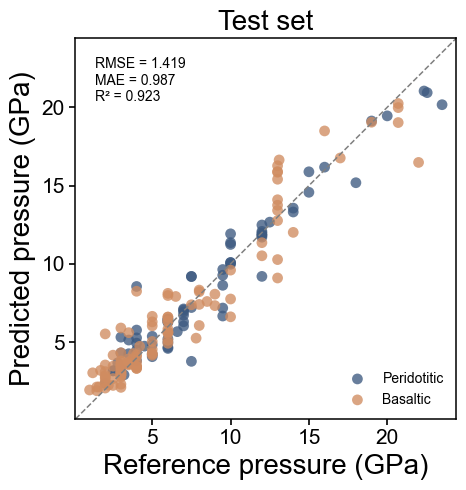

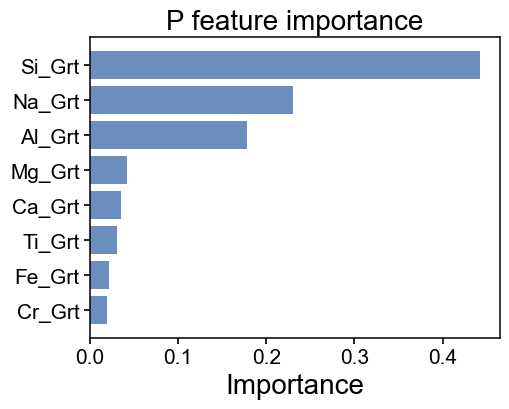

Feature importance saved.

P test predictions saved.


In [37]:
P_train_df = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)
P_test_df = pd.concat([df_P_T_test, df_fO2_test], ignore_index=True)

P_model = train_and_evaluate_pt_model(
    target_name="P",
    train_df=P_train_df,
    test_df=P_test_df,
    figure_prefix="Fig_a_P_model",
    result_filename="P_test_predictions.xlsx",
)

Preparing T model dataset...
Train size: 1612
Test size : 180

Starting 10-fold CV...
Fold 1: RMSE=125.3858, MAE=89.5301, R2=0.7825
Fold 2: RMSE=172.7029, MAE=124.0936, R2=0.7273
Fold 3: RMSE=127.0067, MAE=90.6640, R2=0.7567
Fold 4: RMSE=104.1233, MAE=77.5699, R2=0.8106
Fold 5: RMSE=129.4938, MAE=94.9204, R2=0.7578
Fold 6: RMSE=144.1624, MAE=106.4613, R2=0.7692
Fold 7: RMSE=177.1285, MAE=116.6136, R2=0.6584
Fold 8: RMSE=128.4896, MAE=90.6169, R2=0.8081
Fold 9: RMSE=163.9437, MAE=117.0859, R2=0.6654
Fold 10: RMSE=147.6192, MAE=106.9647, R2=0.7515

CV Results (Mean ± Std):
RMSE: 142.0056 ± 22.2910
MAE : 101.4520 ± 14.2525
R2  : 0.7487 ± 0.0496

CV Results by Lithology (Mean ± Std):

Peridotitic:
  RMSE: 131.3424 ± 18.2875
  MAE : 98.1138 ± 13.2633
  R2  : 0.7288 ± 0.0717

Basaltic:
  RMSE: 147.8497 ± 27.7820
  MAE : 103.5944 ± 16.8816
  R2  : 0.6753 ± 0.0635

Training final T_model...

Test Results:
RMSE: 125.6572
MAE : 93.2677
R2  : 0.8017

Test Results by Lithology:

Peridotitic:
  N  

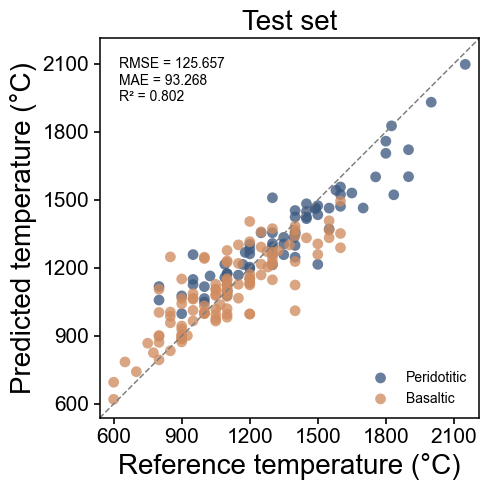

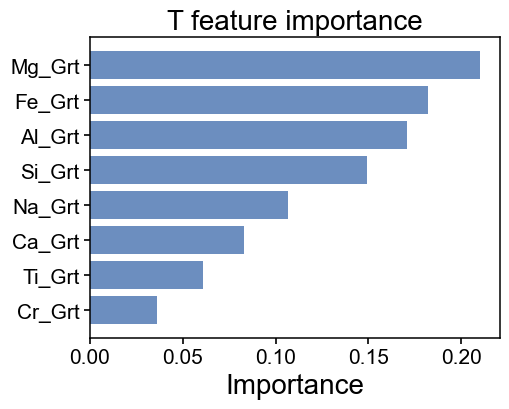

Feature importance saved.

T test predictions saved.


In [38]:
T_train_df = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)
T_test_df = pd.concat([df_P_T_test, df_fO2_test], ignore_index=True)

T_model = train_and_evaluate_pt_model(
    target_name="T",
    train_df=T_train_df,
    test_df=T_test_df,
    figure_prefix="Fig_b_T_model",
    result_filename="T_test_predictions.xlsx",
)

Preparing physics-informed fO2 model...
Generating IW_oof for CV using df_P_T_train + outer-train part of df_fO2_train...
Fold 1: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 2: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 3: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 4: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 5: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 6: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 7: P/T OOF generated using 1571 training samples (1202 from df_P_T_train + 369 from outer-train df_fO2_train)
Fold 8: P/T OOF generated using 1571 training samples (1202 from df_P_T_t

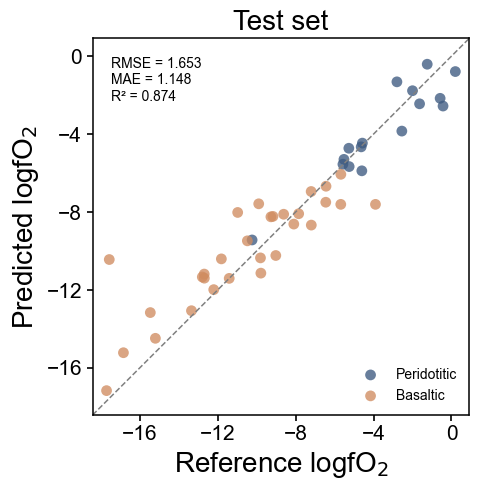

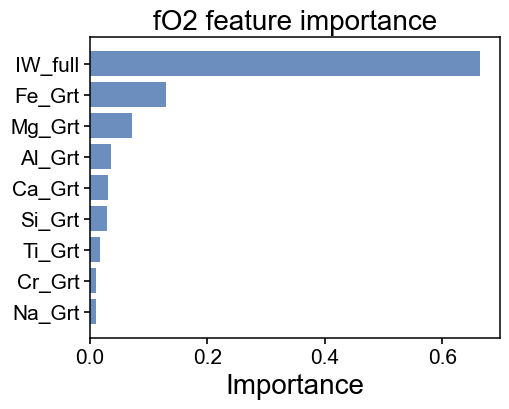

Feature importance saved.

SECTION 3 completed.



In [39]:
print("Preparing physics-informed fO2 model...")

N_SPLITS = 10
USE_IW_FEATURE = True

fO2_train_df = df_fO2_train.copy()
fO2_test_df = df_fO2_test.copy()

# ----------------------------------------------------------
# Base data for fO2 task
# ----------------------------------------------------------
X_base_train = fO2_train_df[BASE_FEATURES].values
y_train = fO2_train_df["fO2"].values

stratify_labels = fO2_train_df[LITHOLOGY_COLUMN].values
test_lithology_labels = fO2_test_df[LITHOLOGY_COLUMN].values

# ----------------------------------------------------------
# Optional: sanity check for required P/T columns
# ----------------------------------------------------------
required_pt_cols = ["P", "T"]
missing_in_pt_train = [c for c in required_pt_cols if c not in df_P_T_train.columns]
missing_in_fo2_train = [c for c in required_pt_cols if c not in fO2_train_df.columns]

if missing_in_pt_train:
    raise KeyError(f"df_P_T_train is missing required columns: {missing_in_pt_train}")
if missing_in_fo2_train:
    raise KeyError(f"df_fO2_train is missing required columns: {missing_in_fo2_train}")

# ----------------------------------------------------------
# Generate IW_oof using:
# df_P_T_train + current outer-train fold of df_fO2_train
# ----------------------------------------------------------
if USE_IW_FEATURE:
    print("Generating IW_oof for CV using df_P_T_train + outer-train part of df_fO2_train...")

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    P_oof = np.zeros(len(fO2_train_df), dtype=float)
    T_oof = np.zeros(len(fO2_train_df), dtype=float)

    for fold, (tr, val) in enumerate(skf.split(X_base_train, stratify_labels), start=1):
        # --------------------------------------------------
        # Outer-train split from df_fO2_train
        # --------------------------------------------------
        fO2_outer_train_df = fO2_train_df.iloc[tr].copy()
        fO2_outer_val_df = fO2_train_df.iloc[val].copy()

        # --------------------------------------------------
        # Build P/T training pool:
        # df_P_T_train + current outer-train part of df_fO2_train
        # --------------------------------------------------
        pt_train_pool = pd.concat(
            [
                df_P_T_train[BASE_FEATURES + ["P", "T"]].copy(),
                fO2_outer_train_df[BASE_FEATURES + ["P", "T"]].copy(),
            ],
            ignore_index=True,
        ).dropna(subset=BASE_FEATURES + ["P", "T"])

        X_pt_train = pt_train_pool[BASE_FEATURES].values
        y_pt_train_P = pt_train_pool["P"].values
        y_pt_train_T = pt_train_pool["T"].values

        X_pt_val = fO2_outer_val_df[BASE_FEATURES].values

        # --------------------------------------------------
        # Train fold-specific P/T models
        # --------------------------------------------------
        model_P_fold = create_model(MODEL_TYPE, "P")
        model_T_fold = create_model(MODEL_TYPE, "T")

        model_P_fold.fit(X_pt_train, y_pt_train_P)
        model_T_fold.fit(X_pt_train, y_pt_train_T)

        # --------------------------------------------------
        # Predict current outer validation fold
        # --------------------------------------------------
        P_oof[val] = model_P_fold.predict(X_pt_val)
        T_oof[val] = model_T_fold.predict(X_pt_val)

        print(
            f"Fold {fold}: "
            f"P/T OOF generated using {len(pt_train_pool)} training samples "
            f"({len(df_P_T_train)} from df_P_T_train + {len(fO2_outer_train_df)} from outer-train df_fO2_train)"
        )

    fO2_train_df["IW_oof"] = calculate_iw(P_oof, T_oof)

# ----------------------------------------------------------
# fO2 model CV
# ----------------------------------------------------------
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

F_FEATURES_CV = BASE_FEATURES + ["IW_oof"] if USE_IW_FEATURE else BASE_FEATURES
X_cv = fO2_train_df[F_FEATURES_CV].values

print("\nStarting 10-fold CV...")

rmse_list, mae_list, r2_list = [], [], []
cv_lith_metrics = {
    LITHOLOGY_1_NAME: {"rmse": [], "mae": [], "r2": []},
    LITHOLOGY_2_NAME: {"rmse": [], "mae": [], "r2": []},
}

best_r2 = -np.inf
best_fold_data = None
best_fold_metrics = None

for fold, (tr, val) in enumerate(skf.split(X_cv, stratify_labels), start=1):
    model = create_model(MODEL_TYPE, "fO2")
    model.fit(X_cv[tr], y_train[tr])

    y_val_pred = model.predict(X_cv[val])
    lith_val = stratify_labels[val]

    rmse = np.sqrt(mean_squared_error(y_train[val], y_val_pred))
    mae = mean_absolute_error(y_train[val], y_val_pred)
    r2 = r2_score(y_train[val], y_val_pred)

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

    print(f"Fold {fold}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

    for lith_label, lith_name in [
        (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
        (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
    ]:
        mask = lith_val == lith_label
        if np.sum(mask) >= 2:
            cv_lith_metrics[lith_name]["rmse"].append(
                np.sqrt(mean_squared_error(y_train[val][mask], y_val_pred[mask]))
            )
            cv_lith_metrics[lith_name]["mae"].append(
                mean_absolute_error(y_train[val][mask], y_val_pred[mask])
            )
            cv_lith_metrics[lith_name]["r2"].append(
                r2_score(y_train[val][mask], y_val_pred[mask])
            )

    if r2 > best_r2:
        best_r2 = r2
        best_fold_data = (y_train[val], y_val_pred, lith_val)
        best_fold_metrics = (rmse, mae, r2)

print("\nCV Results (Mean ± Std):")
print(f"RMSE: {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")
print(f"MAE : {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f}")
print(f"R2  : {np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}")

print("\nCV Results by Lithology (Mean ± Std):")
for lith_name in [LITHOLOGY_1_NAME, LITHOLOGY_2_NAME]:
    print(f"\n{lith_name}:")
    print(
        f"  RMSE: {np.mean(cv_lith_metrics[lith_name]['rmse']):.4f} ± "
        f"{np.std(cv_lith_metrics[lith_name]['rmse']):.4f}"
    )
    print(
        f"  MAE : {np.mean(cv_lith_metrics[lith_name]['mae']):.4f} ± "
        f"{np.std(cv_lith_metrics[lith_name]['mae']):.4f}"
    )
    print(
        f"  R2  : {np.mean(cv_lith_metrics[lith_name]['r2']):.4f} ± "
        f"{np.std(cv_lith_metrics[lith_name]['r2']):.4f}"
    )

# ----------------------------------------------------------
# Final training for fO2 model
# ----------------------------------------------------------
if USE_IW_FEATURE:
    print("\nGenerating IW_full for final training...")

    # Final P/T models are assumed to be the already-trained formal P_model/T_model
    # These models can use the full training information available upstream.
    P_full_train = P_model.predict(X_base_train)
    T_full_train = T_model.predict(X_base_train)

    fO2_train_df["IW_full"] = calculate_iw(P_full_train, T_full_train)
    F_FEATURES_FINAL = BASE_FEATURES + ["IW_full"]
else:
    F_FEATURES_FINAL = BASE_FEATURES

X_train_final = fO2_train_df[F_FEATURES_FINAL].values

print("\nTraining final fO2_model...")

fO2_model = create_model(MODEL_TYPE, "fO2")
fO2_model.fit(X_train_final, y_train)

joblib.dump(fO2_model, os.path.join(MODEL_PATH, f"fO2_model_{MODEL_TYPE}.pkl"))
print("fO2 model saved.")

# ----------------------------------------------------------
# Test evaluation
# ----------------------------------------------------------
print("\nEvaluating on test set...")

X_base_test = fO2_test_df[BASE_FEATURES].values
y_test = fO2_test_df["fO2"].values

if USE_IW_FEATURE:
    P_test = P_model.predict(X_base_test)
    T_test = T_model.predict(X_base_test)
    fO2_test_df["IW_full"] = calculate_iw(P_test, T_test)

X_test = fO2_test_df[F_FEATURES_FINAL].values
y_test_pred = fO2_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Results:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"R2  : {test_r2:.4f}")

print("\nTest Results by Lithology:")
for lith_label, lith_name in [
    (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
    (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
]:
    mask = test_lithology_labels == lith_label
    y_true_l = y_test[mask]
    y_pred_l = y_test_pred[mask]
    residual_l = y_true_l - y_pred_l
    abs_error_l = np.abs(residual_l)

    print(f"\n{lith_name}:")
    print(f"  N   : {np.sum(mask)}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_true_l, y_pred_l)):.4f}")
    print(f"  MAE : {mean_absolute_error(y_true_l, y_pred_l):.4f}")
    print(f"  R2  : {r2_score(y_true_l, y_pred_l):.4f}")
    print(f"  Residual mean ± std : {np.mean(residual_l):.4f} ± {np.std(residual_l):.4f}")
    print(f"  Abs error mean ± std: {np.mean(abs_error_l):.4f} ± {np.std(abs_error_l):.4f}")

metrics_text = (
    f"RMSE = {test_rmse:.3f}\n"
    f"MAE = {test_mae:.3f}\n"
    f"R² = {test_r2:.3f}"
)

plot_reference_prediction_panel(
    y_ref=y_test,
    y_pred=y_test_pred,
    lithology_code=test_lithology_labels,
    xlabel=r"Reference logfO$_2$",
    ylabel=r"Predicted logfO$_2$",
    save_png=os.path.join(IMAGE_PATH, "Fig_c_fO2_model.png"),
    save_pdf=os.path.join(IMAGE_PATH, "Fig_c_fO2_model.pdf"),
    title="Test set",
    metrics_text=metrics_text,
    figsize=(5.2, 5.0),
)

test_result = pd.DataFrame(
    {
        "logfO2_reference": y_test,
        "logfO2_pred": y_test_pred,
        "lithology": test_lithology_labels,
    }
)
test_result["residual"] = (
    test_result["logfO2_reference"] - test_result["logfO2_pred"]
)
test_result["abs_error"] = np.abs(test_result["residual"])

test_result.to_excel(
    os.path.join(RESULT_DIR, "logfO2_test_predictions.xlsx"),
    index=False,
)

# ----------------------------------------------------------
# Feature importance for XGBoost / RF
# ----------------------------------------------------------
if MODEL_TYPE in ["xgboost", "rf"]:
    print("\nComputing feature importance...")

    importance = fO2_model.feature_importances_
    feature_names = BASE_FEATURES + ["IW_full"] if USE_IW_FEATURE else BASE_FEATURES

    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importance,
        }
    ).sort_values("importance", ascending=False)

    print("\nFeature Importance:")
    print(importance_df)

    set_sa_style()
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    ax.barh(importance_df["feature"], importance_df["importance"], color="#6C8EBF")
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    ax.set_title("fO2 feature importance", pad=6)
    beautify_axis(ax)

    plt.tight_layout()
    plt.savefig(
        os.path.join(IMAGE_PATH, f"{MODEL_TYPE}_fO2_feature_importance.png"),
        bbox_inches="tight",
    )
    plt.savefig(
        os.path.join(IMAGE_PATH, f"{MODEL_TYPE}_fO2_feature_importance.pdf"),
        bbox_inches="tight",
    )
    plt.show()

    importance_df.to_excel(
        os.path.join(RESULT_DIR, f"{MODEL_TYPE}_fO2_feature_importance.xlsx"),
        index=False,
    )

    print("Feature importance saved.\n")

print("SECTION 3 completed.\n")

Calculating reference and predicted ΔIW on test set...


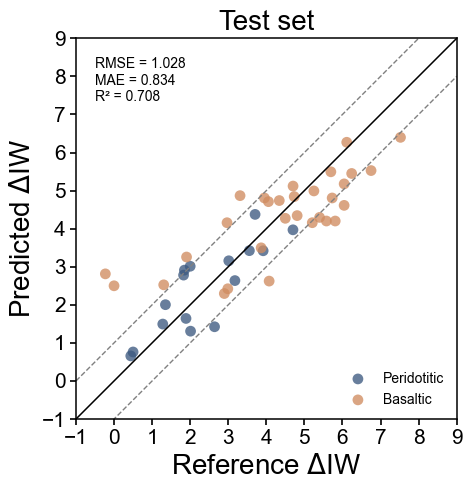


Overall ΔIW Test Results:
RMSE: 1.0277
MAE : 0.8336
R2  : 0.7084

ΔIW Test Results by Lithology:

Peridotitic:
  N   : 16
  RMSE: 0.6729
  MAE : 0.5783
  R2  : 0.6802
  Residual mean ± std : -0.0704 ± 0.6692
  Abs error mean ± std: 0.5783 ± 0.3440

Basaltic:
  N   : 30
  RMSE: 1.1738
  MAE : 0.9698
  R2  : 0.5923
  Residual mean ± std : 0.0729 ± 1.1716
  Abs error mean ± std: 0.9698 ± 0.6613


In [41]:
# ==========================================================
# CELL 12 — ΔIW COMPARISON (UNIFIED SA STYLE)
# ==========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Calculating reference and predicted ΔIW on test set...")

P_ref = fO2_test_df["P"].values
T_ref = fO2_test_df["T"].values
fO2_ref = fO2_test_df["fO2"].values

IW_ref = calculate_iw(P_ref, T_ref)
dIW_ref = fO2_ref - IW_ref

IW_pred = calculate_iw(P_test, T_test)
dIW_pred = y_test_pred - IW_pred

lithology_code = fO2_test_df[LITHOLOGY_COLUMN].values

diw_rmse, diw_mae, diw_r2 = plot_delta_buffer_panel(
    x_ref=dIW_ref,
    y_pred=dIW_pred,
    lithology_code=lithology_code,
    delta_name=r"$\Delta$IW",
    save_png=os.path.join(IMAGE_PATH, "Fig_d_dIW_model.png"),
    save_pdf=os.path.join(IMAGE_PATH, "Fig_d_dIW_model.pdf"),
    title="Test set",
    figsize=(5.2, 5.0),
)

print("\nOverall ΔIW Test Results:")
print(f"RMSE: {diw_rmse:.4f}")
print(f"MAE : {diw_mae:.4f}")
print(f"R2  : {diw_r2:.4f}")

print("\nΔIW Test Results by Lithology:")
for lith_label, lith_name in [
    (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
    (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
]:
    mask = lithology_code == lith_label

    if np.sum(mask) == 0:
        print(f"\n{lith_name}:")
        print("  N   : 0")
        print("  No samples.")
        continue

    dIW_ref_l = dIW_ref[mask]
    dIW_pred_l = dIW_pred[mask]

    rmse_l = np.sqrt(mean_squared_error(dIW_ref_l, dIW_pred_l))
    mae_l = mean_absolute_error(dIW_ref_l, dIW_pred_l)
    r2_l = r2_score(dIW_ref_l, dIW_pred_l) if np.sum(mask) >= 2 else np.nan

    residual_l = dIW_ref_l - dIW_pred_l
    abs_error_l = np.abs(residual_l)

    print(f"\n{lith_name}:")
    print(f"  N   : {np.sum(mask)}")
    print(f"  RMSE: {rmse_l:.4f}")
    print(f"  MAE : {mae_l:.4f}")
    print(f"  R2  : {r2_l:.4f}" if not np.isnan(r2_l) else "  R2  : nan")
    print(f"  Residual mean ± std : {np.mean(residual_l):.4f} ± {np.std(residual_l):.4f}")
    print(f"  Abs error mean ± std: {np.mean(abs_error_l):.4f} ± {np.std(abs_error_l):.4f}")

Calculating reference and predicted ΔFMQ on test set...


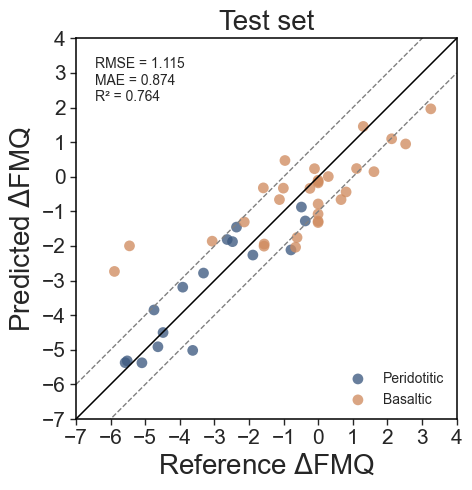


Overall ΔFMQ Test Results:
RMSE: 1.1152
MAE : 0.8737
R2  : 0.7642

ΔFMQ Test Results by Lithology:

Peridotitic:
  N   : 16
  RMSE: 0.7289
  MAE : 0.6153
  R2  : 0.8145
  Residual mean ± std : 0.0044 ± 0.7289
  Abs error mean ± std: 0.6153 ± 0.3908

Basaltic:
  N   : 30
  RMSE: 1.2742
  MAE : 1.0115
  R2  : 0.5687
  Residual mean ± std : 0.1467 ± 1.2658
  Abs error mean ± std: 1.0115 ± 0.7749


In [47]:
# ==========================================================
# CELL 13 — ΔFMQ COMPARISON (UNIFIED SA STYLE)
# ==========================================================
print("Calculating reference and predicted ΔFMQ on test set...")

FMQ_ref = fmq_hp2011(P_ref, T_ref)
dFMQ_ref = fO2_ref - FMQ_ref

FMQ_pred = fmq_hp2011(P_test, T_test)
dFMQ_pred = y_test_pred - FMQ_pred

dfmq_rmse, dfmq_mae, dfmq_r2 = plot_delta_buffer_panel(
    x_ref=dFMQ_ref,
    y_pred=dFMQ_pred,
    lithology_code=lithology_code,
    delta_name=r"$\Delta$FMQ",
    save_png=os.path.join(IMAGE_PATH, "Fig_e_dFMQ_model.png"),
    save_pdf=os.path.join(IMAGE_PATH, "Fig_e_dFMQ_model.pdf"),
    title="Test set",
    figsize=(5.2, 5.0),
)

print("\nOverall ΔFMQ Test Results:")
print(f"RMSE: {dfmq_rmse:.4f}")
print(f"MAE : {dfmq_mae:.4f}")
print(f"R2  : {dfmq_r2:.4f}")

print("\nΔFMQ Test Results by Lithology:")
for lith_label, lith_name in [
    (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
    (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
]:
    mask = lithology_code == lith_label

    if np.sum(mask) == 0:
        print(f"\n{lith_name}:")
        print("  N   : 0")
        print("  No samples.")
        continue

    dFMQ_ref_l = dFMQ_ref[mask]
    dFMQ_pred_l = dFMQ_pred[mask]

    rmse_l = np.sqrt(mean_squared_error(dFMQ_ref_l, dFMQ_pred_l))
    mae_l = mean_absolute_error(dFMQ_ref_l, dFMQ_pred_l)
    r2_l = r2_score(dFMQ_ref_l, dFMQ_pred_l) if np.sum(mask) >= 2 else np.nan

    residual_l = dFMQ_ref_l - dFMQ_pred_l
    abs_error_l = np.abs(residual_l)

    print(f"\n{lith_name}:")
    print(f"  N   : {np.sum(mask)}")
    print(f"  RMSE: {rmse_l:.4f}")
    print(f"  MAE : {mae_l:.4f}")
    print(f"  R2  : {r2_l:.4f}" if not np.isnan(r2_l) else "  R2  : nan")
    print(f"  Residual mean ± std : {np.mean(residual_l):.4f} ± {np.std(residual_l):.4f}")
    print(f"  Abs error mean ± std: {np.mean(abs_error_l):.4f} ± {np.std(abs_error_l):.4f}")

Calculating reference and predicted ΔNNO on test set...


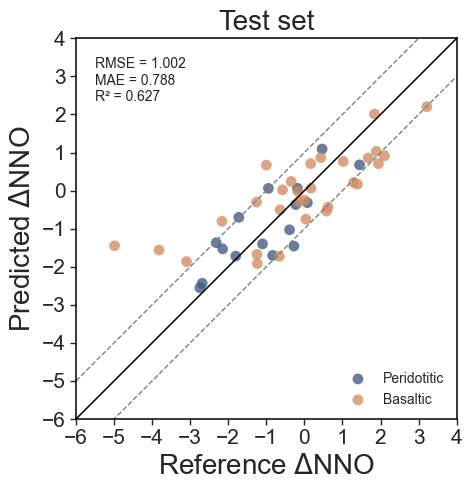


Overall ΔNNO Test Results:
RMSE: 1.0024
MAE : 0.7876
R2  : 0.6265

ΔNNO Test Results by Lithology:

Peridotitic:
  N   : 16
  RMSE: 0.6757
  MAE : 0.5801
  R2  : 0.6615
  Residual mean ± std : -0.0430 ± 0.6744
  Abs error mean ± std: 0.5801 ± 0.3466

Basaltic:
  N   : 30
  RMSE: 1.1390
  MAE : 0.8983
  R2  : 0.5877
  Residual mean ± std : -0.0099 ± 1.1389
  Abs error mean ± std: 0.8983 ± 0.7002
ΔNNO predictions saved.


In [48]:
# ==========================================================
# CELL 14 — ΔNNO COMPARISON (UNIFIED SA STYLE)
# ==========================================================
print("Calculating reference and predicted ΔNNO on test set...")

P_ref = fO2_test_df["P"].values
T_ref = fO2_test_df["T"].values
fO2_ref = fO2_test_df["fO2"].values

NNO_ref = nno_campbell2009(P_ref, T_ref)
dNNO_ref = fO2_ref - NNO_ref

NNO_pred = nno_campbell2009(P_test, T_test)
dNNO_pred = y_test_pred - NNO_pred

lithology_code = fO2_test_df[LITHOLOGY_COLUMN].values

dnno_rmse, dnno_mae, dnno_r2 = plot_delta_buffer_panel(
    x_ref=dNNO_ref,
    y_pred=dNNO_pred,
    lithology_code=lithology_code,
    delta_name=r"$\Delta$NNO",
    save_png=os.path.join(IMAGE_PATH, "Fig_f_dNNO_model.png"),
    save_pdf=os.path.join(IMAGE_PATH, "Fig_f_dNNO_model.pdf"),
    title="Test set",
    figsize=(5.2, 5.0),
)

print("\nOverall ΔNNO Test Results:")
print(f"RMSE: {dnno_rmse:.4f}")
print(f"MAE : {dnno_mae:.4f}")
print(f"R2  : {dnno_r2:.4f}")

print("\nΔNNO Test Results by Lithology:")
for lith_label, lith_name in [
    (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
    (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
]:
    mask = lithology_code == lith_label

    if np.sum(mask) == 0:
        print(f"\n{lith_name}:")
        print("  N   : 0")
        print("  No samples.")
        continue

    dNNO_ref_l = dNNO_ref[mask]
    dNNO_pred_l = dNNO_pred[mask]

    rmse_l = np.sqrt(mean_squared_error(dNNO_ref_l, dNNO_pred_l))
    mae_l = mean_absolute_error(dNNO_ref_l, dNNO_pred_l)
    r2_l = r2_score(dNNO_ref_l, dNNO_pred_l) if np.sum(mask) >= 2 else np.nan

    residual_l = dNNO_ref_l - dNNO_pred_l
    abs_error_l = np.abs(residual_l)

    print(f"\n{lith_name}:")
    print(f"  N   : {np.sum(mask)}")
    print(f"  RMSE: {rmse_l:.4f}")
    print(f"  MAE : {mae_l:.4f}")
    print(f"  R2  : {r2_l:.4f}" if not np.isnan(r2_l) else "  R2  : nan")
    print(f"  Residual mean ± std : {np.mean(residual_l):.4f} ± {np.std(residual_l):.4f}")
    print(f"  Abs error mean ± std: {np.mean(abs_error_l):.4f} ± {np.std(abs_error_l):.4f}")

dnno_result = pd.DataFrame({
    "lithology_code": lithology_code,
    "P_reference": P_ref,
    "T_reference": T_ref,
    "fO2_reference": fO2_ref,
    "NNO_reference": NNO_ref,
    "dNNO_reference": dNNO_ref,
    "P_pred": P_test,
    "T_pred": T_test,
    "fO2_pred": y_test_pred,
    "NNO_pred": NNO_pred,
    "dNNO_pred": dNNO_pred,
})

dnno_result["residual_dNNO"] = dnno_result["dNNO_reference"] - dnno_result["dNNO_pred"]
dnno_result["abs_error_dNNO"] = np.abs(dnno_result["residual_dNNO"])

dnno_result.to_excel(
    os.path.join(RESULT_DIR, "dNNO_test_predictions.xlsx"),
    index=False
)

print("ΔNNO predictions saved.")

Calculating reference and predicted ΔMH on test set...


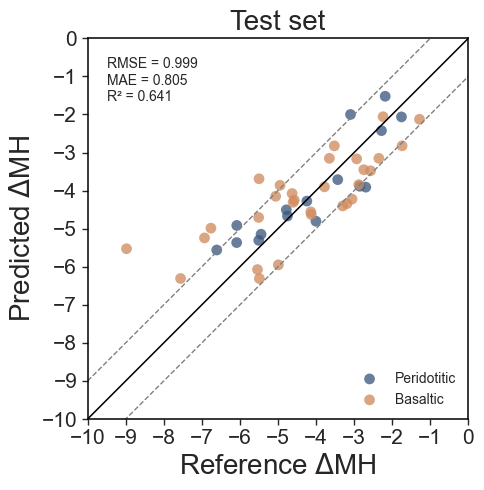


Overall ΔMH Test Results:
RMSE: 0.9995
MAE : 0.8046
R2  : 0.6406

ΔMH Test Results by Lithology:

Peridotitic:
  N   : 16
  RMSE: 0.7164
  MAE : 0.5851
  R2  : 0.7739
  Residual mean ± std : -0.1073 ± 0.7083
  Abs error mean ± std: 0.5851 ± 0.4134

Basaltic:
  N   : 30
  RMSE: 1.1216
  MAE : 0.9216
  R2  : 0.5863
  Residual mean ± std : -0.0986 ± 1.1173
  Abs error mean ± std: 0.9216 ± 0.6393
ΔMH predictions saved.


In [49]:
# ==========================================================
# CELL 15 — ΔMH COMPARISON (UNIFIED SA STYLE)
# ==========================================================
print("Calculating reference and predicted ΔMH on test set...")

P_ref = fO2_test_df["P"].values
T_ref = fO2_test_df["T"].values
fO2_ref = fO2_test_df["fO2"].values

MH_ref = mh_schwab1981(P_ref, T_ref)
dMH_ref = fO2_ref - MH_ref

MH_pred = mh_schwab1981(P_test, T_test)
dMH_pred = y_test_pred - MH_pred

lithology_code = fO2_test_df[LITHOLOGY_COLUMN].values

dmh_rmse, dmh_mae, dmh_r2 = plot_delta_buffer_panel(
    x_ref=dMH_ref,
    y_pred=dMH_pred,
    lithology_code=lithology_code,
    delta_name=r"$\Delta$MH",
    save_png=os.path.join(IMAGE_PATH, "Fig_g_dMH_model.png"),
    save_pdf=os.path.join(IMAGE_PATH, "Fig_g_dMH_model.pdf"),
    title="Test set",
    figsize=(5.2, 5.0),
)

print("\nOverall ΔMH Test Results:")
print(f"RMSE: {dmh_rmse:.4f}")
print(f"MAE : {dmh_mae:.4f}")
print(f"R2  : {dmh_r2:.4f}")

print("\nΔMH Test Results by Lithology:")
for lith_label, lith_name in [
    (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
    (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
]:
    mask = lithology_code == lith_label

    if np.sum(mask) == 0:
        print(f"\n{lith_name}:")
        print("  N   : 0")
        print("  No samples.")
        continue

    dMH_ref_l = dMH_ref[mask]
    dMH_pred_l = dMH_pred[mask]

    rmse_l = np.sqrt(mean_squared_error(dMH_ref_l, dMH_pred_l))
    mae_l = mean_absolute_error(dMH_ref_l, dMH_pred_l)
    r2_l = r2_score(dMH_ref_l, dMH_pred_l) if np.sum(mask) >= 2 else np.nan

    residual_l = dMH_ref_l - dMH_pred_l
    abs_error_l = np.abs(residual_l)

    print(f"\n{lith_name}:")
    print(f"  N   : {np.sum(mask)}")
    print(f"  RMSE: {rmse_l:.4f}")
    print(f"  MAE : {mae_l:.4f}")
    print(f"  R2  : {r2_l:.4f}" if not np.isnan(r2_l) else "  R2  : nan")
    print(f"  Residual mean ± std : {np.mean(residual_l):.4f} ± {np.std(residual_l):.4f}")
    print(f"  Abs error mean ± std: {np.mean(abs_error_l):.4f} ± {np.std(abs_error_l):.4f}")

dmh_result = pd.DataFrame({
    "lithology_code": lithology_code,
    "P_reference": P_ref,
    "T_reference": T_ref,
    "fO2_reference": fO2_ref,
    "MH_reference": MH_ref,
    "dMH_reference": dMH_ref,
    "P_pred": P_test,
    "T_pred": T_test,
    "fO2_pred": y_test_pred,
    "MH_pred": MH_pred,
    "dMH_pred": dMH_pred,
})

dmh_result["residual_dMH"] = dmh_result["dMH_reference"] - dmh_result["dMH_pred"]
dmh_result["abs_error_dMH"] = np.abs(dmh_result["residual_dMH"])

dmh_result.to_excel(
    os.path.join(RESULT_DIR, "dMH_test_predictions.xlsx"),
    index=False
)

print("ΔMH predictions saved.")

Running full oxybarometer pipeline...

Feature range summary from combined training set:
feature      q01      q99      min      max
 Si_Grt 2.918784 3.668381 2.874297 3.821459
 Ti_Grt 0.000000 0.121193 0.000000 0.259340
 Al_Grt 0.583500 2.036326 0.375973 2.166703
 Cr_Grt 0.000000 0.389571 0.000000 0.675842
 Fe_Grt 0.180813 1.882988 0.034183 2.112534
 Mg_Grt 0.341043 3.211790 0.019318 3.449352
 Ca_Grt 0.016439 1.374694 0.000000 1.925556
 Na_Grt 0.000000 0.419222 0.000000 0.602441

Running feature-wise range screening (1st–99th percentile)...
Feature-wise range OOD ratio: 19.19 %

Running feature-space OOD detection...
Feature-space OOD k: 3
Feature-space OOD threshold (99th percentile): 1.4641
Feature-space OOD ratio: 2.02 %

Predicting P and T...
Mean P: 5.631
Mean T: 1243.358 

Running P–T OOD detection on the combined training set...
P–T OOD k: 3
P–T OOD threshold (95th percentile): 0.1761
P–T OOD ratio: 0.0 %

Mean IW: -9.326 

Mean logfO2: -5.772
Mean ΔIW: 3.554 

Running PCA visu

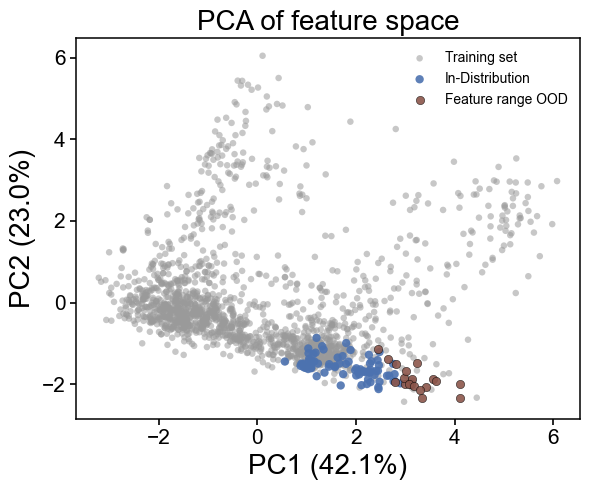

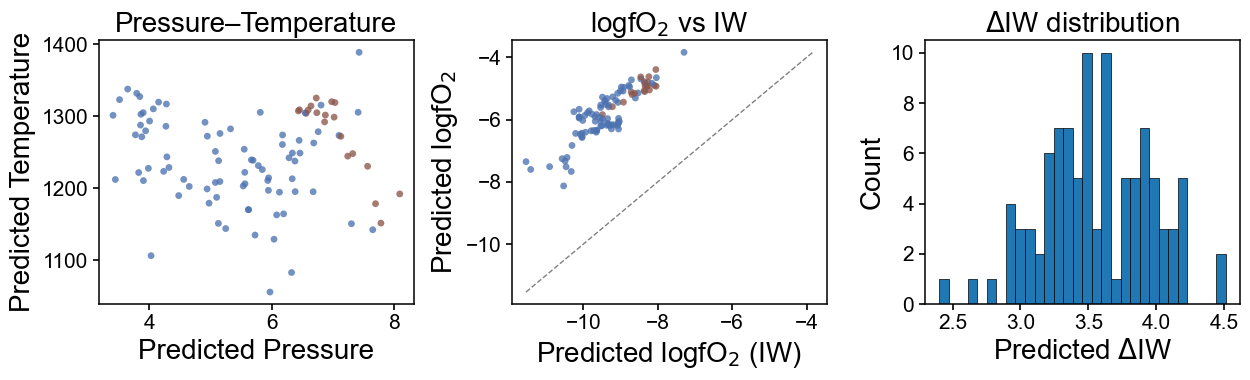

Saved prediction results to: results\sample1_oxybarometer_predictions.xlsx
Saved feature range summary to: results\sample1_feature_range_summary.xlsx



In [42]:
warnings.filterwarnings("ignore", category=UserWarning)

df_predict_result, feature_range_df = run_full_oxybarometer_pipeline(
    df_predict=df_predict1,
    prediction_name="sample1",
    df_P_T_train=df_P_T_train,
    df_fO2_train=df_fO2_train,
    BASE_FEATURES=BASE_FEATURES,
    P_model=P_model,
    T_model=T_model,
    fO2_model=fO2_model,
    calculate_iw=calculate_iw,
    RESULT_DIR=RESULT_DIR,
    RANDOM_STATE=RANDOM_STATE,
)


Total samples: 99
Total Peridotitic samples: 99
Peridotitic + In-Distribution: 80
Peridotitic + P-T OOD: 0
Peridotitic + Feature OOD: 0
Peridotitic + Feature range OOD: 19

Distribution flag counts:
distribution_flag
In-Distribution      80
Feature range OOD    19
Name: count, dtype: int64

Residual summary (Peridotitic + In-Distribution only):
count    80.000000
mean      0.236191
std       0.695952
min      -1.441772
25%      -0.233459
50%       0.238619
75%       0.692405
max       2.007538
Name: residual_dFMQ, dtype: float64

Mean bias (Peridotitic + In-Distribution): 0.2362
Mean Absolute Error, MAE (Peridotitic + In-Distribution): 0.5762
Root Mean Squared Error, RMSE (Peridotitic + In-Distribution): 0.7308
Percentage within ±1.2 (Peridotitic + In-Distribution): 87.50%
±1.5239 contains 95% of samples (Peridotitic + In-Distribution)


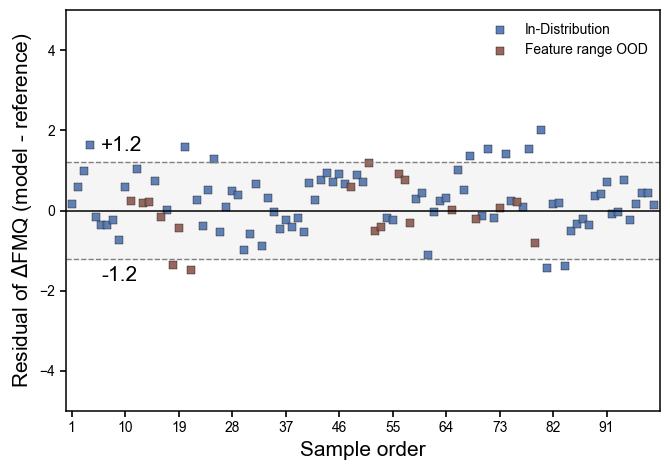

In [43]:
set_sa_style()

# ----------------------------------------------------------
# Prepare input DataFrame
# ----------------------------------------------------------
if isinstance(df_predict_result, tuple):
    plot_df = df_predict_result[0].copy()
else:
    plot_df = df_predict_result.copy()

# ----------------------------------------------------------
# Check required columns
# ----------------------------------------------------------
required_columns = [
    "P_pred",
    "T_pred",
    "logfO2_pred",
    "distribution_flag",
    "type",
]

missing_required = [col for col in required_columns if col not in plot_df.columns]
if len(missing_required) > 0:
    raise KeyError(
        f"Missing required columns in df_predict_result: {missing_required}"
    )

if "dFMQ" not in plot_df.columns:
    raise KeyError(
        "Column 'dFMQ' was not found in df_predict_result. "
        "Residual dFMQ cannot be calculated without the reference dFMQ column."
    )

# ----------------------------------------------------------
# Compute residual
# ----------------------------------------------------------
plot_df["FMQ_pred"] = fmq_hp2011(
    plot_df["P_pred"],
    plot_df["T_pred"]
)

plot_df["dFMQ2"] = plot_df["logfO2_pred"] - plot_df["FMQ_pred"]
plot_df["residual_dFMQ"] = plot_df["dFMQ2"] - plot_df["dFMQ"]

plot_df["type"] = plot_df["type"].astype(str).str.strip().str.lower()
plot_df["distribution_flag"] = plot_df["distribution_flag"].astype(str).str.strip()

# ----------------------------------------------------------
# Filter for Peridotitic only
# ----------------------------------------------------------
peridotite_df = plot_df[plot_df["type"] == "peridotite"].copy()
peridotite_df = peridotite_df.reset_index(drop=True)
peridotite_df["sample_order"] = np.arange(1, len(peridotite_df) + 1)

# ----------------------------------------------------------
# Split by final four-category framework
# ----------------------------------------------------------
in_dist_df = peridotite_df[
    peridotite_df["distribution_flag"] == "In-Distribution"
].copy()

pt_ood_df = peridotite_df[
    peridotite_df["distribution_flag"] == "P-T OOD"
].copy()

feature_ood_df = peridotite_df[
    peridotite_df["distribution_flag"] == "Feature OOD"
].copy()

feature_range_ood_df = peridotite_df[
    peridotite_df["distribution_flag"] == "Feature range OOD"
].copy()

non_ood_df = in_dist_df.copy()

# ----------------------------------------------------------
# Print counts
# ----------------------------------------------------------
print("Total samples:", len(plot_df))
print("Total Peridotitic samples:", len(peridotite_df))
print("Peridotitic + In-Distribution:", len(in_dist_df))
print("Peridotitic + P-T OOD:", len(pt_ood_df))
print("Peridotitic + Feature OOD:", len(feature_ood_df))
print("Peridotitic + Feature range OOD:", len(feature_range_ood_df))

print("\nDistribution flag counts:")
print(peridotite_df["distribution_flag"].value_counts(dropna=False))

print("\nResidual summary (Peridotitic + In-Distribution only):")
print(non_ood_df["residual_dFMQ"].describe())

# ----------------------------------------------------------
# Agreement / bias metrics
# ----------------------------------------------------------
residual = non_ood_df["residual_dFMQ"].dropna().values

if len(residual) == 0:
    print("\nNo fully in-distribution Peridotitic samples were available for statistics.")
else:
    mean_bias = np.mean(residual)
    mae = np.mean(np.abs(residual))
    rmse = np.sqrt(np.mean(residual**2))
    within_err_pct = np.mean(np.abs(residual) <= 1.2) * 100
    x_95 = np.percentile(np.abs(residual), 95)

    print(f"\nMean bias (Peridotitic + In-Distribution): {mean_bias:.4f}")
    print(f"Mean Absolute Error, MAE (Peridotitic + In-Distribution): {mae:.4f}")
    print(f"Root Mean Squared Error, RMSE (Peridotitic + In-Distribution): {rmse:.4f}")
    print(f"Percentage within ±1.2 (Peridotitic + In-Distribution): {within_err_pct:.2f}%")
    print(f"±{x_95:.4f} contains 95% of samples (Peridotitic + In-Distribution)")

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.8, 4.8))

if len(in_dist_df) > 0:
    ax.scatter(
        in_dist_df["sample_order"],
        in_dist_df["residual_dFMQ"],
        marker="s",
        s=32,
        facecolors=COLOR_ID,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.90,
        label="In-Distribution",
    )

if len(pt_ood_df) > 0:
    ax.scatter(
        pt_ood_df["sample_order"],
        pt_ood_df["residual_dFMQ"],
        marker="s",
        s=32,
        facecolors=COLOR_PT_OOD,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.90,
        label="P-T OOD",
    )

if len(feature_ood_df) > 0:
    ax.scatter(
        feature_ood_df["sample_order"],
        feature_ood_df["residual_dFMQ"],
        marker="s",
        s=32,
        facecolors=COLOR_FEATURE_OOD,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.90,
        label="Feature OOD",
    )

if len(feature_range_ood_df) > 0:
    ax.scatter(
        feature_range_ood_df["sample_order"],
        feature_range_ood_df["residual_dFMQ"],
        marker="s",
        s=32,
        facecolors=COLOR_FEATURE_RANGE_OOD,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.90,
        label="Feature range OOD",
    )

ax.axhline(0, linestyle="-", linewidth=1.1, color="black")
ax.axhline(1.2, linestyle="--", linewidth=1.0, color="gray")
ax.axhline(-1.2, linestyle="--", linewidth=1.0, color="gray")

x_min, x_max = 1, len(peridotite_df)
if x_max >= 1:
    ax.fill_between([x_min - 1, x_max + 1], -1.2, 1.2, alpha=0.08, color="gray")

    x_text = max(1, x_max * 0.06)
    offset = 0.18
    ax.text(x_text, 1.2 + offset, "+1.2", ha="left", va="bottom",fontsize=15)
    ax.text(x_text, -1.2 - offset, "-1.2", ha="left", va="top",fontsize=15)

ax.set_xlabel("Sample order",fontsize=15)
ax.set_ylabel(r"Residual of $\Delta$FMQ (model - reference)",fontsize=15)

ax.set_ylim(-5, 5)
ax.set_xlim(x_min - 1, max(x_max + 1, 1))
ax.margins(x=0)

if len(peridotite_df) > 40:
    step = max(1, len(peridotite_df) // 10)
    ax.set_xticks(np.arange(1, len(peridotite_df) + 1, step))
elif len(peridotite_df) > 0:
    ax.set_xticks(np.arange(1, len(peridotite_df) + 1))

beautify_axis(ax)
ax.legend(frameon=False, loc="best")
ax.tick_params(labelsize=10)

plt.tight_layout()

os.makedirs(IMAGE_PATH, exist_ok=True)

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        f"{MODEL_TYPE}_dFMQ_residual_peridotitic_with_final_four_categories.png",
    ),
    bbox_inches="tight",
)
plt.savefig(
    os.path.join(
        IMAGE_PATH,
        f"{MODEL_TYPE}_dFMQ_residual_peridotitic_with_final_four_categories.pdf",
    ),
    bbox_inches="tight",
)

plt.show()

Running full oxybarometer pipeline...

Feature range summary from combined training set:
feature      q01      q99      min      max
 Si_Grt 2.918784 3.668381 2.874297 3.821459
 Ti_Grt 0.000000 0.121193 0.000000 0.259340
 Al_Grt 0.583500 2.036326 0.375973 2.166703
 Cr_Grt 0.000000 0.389571 0.000000 0.675842
 Fe_Grt 0.180813 1.882988 0.034183 2.112534
 Mg_Grt 0.341043 3.211790 0.019318 3.449352
 Ca_Grt 0.016439 1.374694 0.000000 1.925556
 Na_Grt 0.000000 0.419222 0.000000 0.602441

Running feature-wise range screening (1st–99th percentile)...
Feature-wise range OOD ratio: 2.53 %

Running feature-space OOD detection...
Feature-space OOD k: 3
Feature-space OOD threshold (99th percentile): 1.4641
Feature-space OOD ratio: 0.95 %

Predicting P and T...
Mean P: 6.945
Mean T: 1160.855 

Running P–T OOD detection on the combined training set...
P–T OOD k: 3
P–T OOD threshold (95th percentile): 0.1761
P–T OOD ratio: 0.95 %

Mean IW: -9.921 

Mean logfO2: -7.116
Mean ΔIW: 2.805 

Running PCA visu

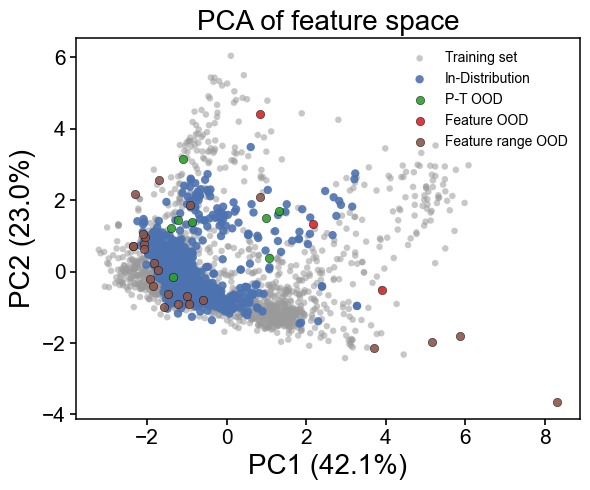

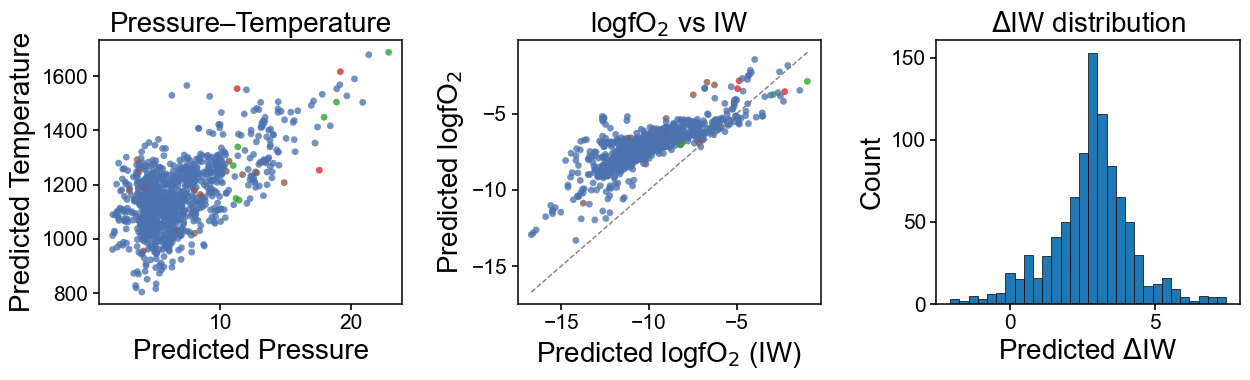

Saved prediction results to: results\sample2_oxybarometer_predictions.xlsx
Saved feature range summary to: results\sample2_feature_range_summary.xlsx



In [19]:
warnings.filterwarnings("ignore", category=UserWarning)

df_predict_result, feature_range_df = run_full_oxybarometer_pipeline(
    df_predict=df_predict2,
    prediction_name="sample2",
    df_P_T_train=df_P_T_train,
    df_fO2_train=df_fO2_train,
    BASE_FEATURES=BASE_FEATURES,
    P_model=P_model,
    T_model=T_model,
    fO2_model=fO2_model,
    calculate_iw=calculate_iw,
    RESULT_DIR=RESULT_DIR,
    RANDOM_STATE=RANDOM_STATE,
)

In [128]:
# ==============================================================
# FULL PER-SAMPLE SHAP MODULE
# Stable version
# ==============================================================

import shapiq

warnings.filterwarnings("ignore")

print("\n========== STARTING FULL PER-SAMPLE SHAP ==========\n")

SHAP_TARGET_MODEL = "ALL"  # "P" / "T" / "fO2" / "ALL"
SHAP_BUDGET = 500

SHAP_ROOT = os.path.join(RESULT_DIR, "SHAP_results")
os.makedirs(SHAP_ROOT, exist_ok=True)


# ==============================================================
# DATA PREPARATION
# ==============================================================

def prepare_data(model_name):
    if model_name == "P":
        train_df = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)
        test_df = pd.concat([df_P_T_test, df_fO2_test], ignore_index=True)
        feature_list = BASE_FEATURES
        target = "P"

    elif model_name == "T":
        train_df = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)
        test_df = pd.concat([df_P_T_test, df_fO2_test], ignore_index=True)
        feature_list = BASE_FEATURES
        target = "T"

    elif model_name == "fO2":
        train_df = df_fO2_train.copy()
        test_df = df_fO2_test.copy()
        feature_list = BASE_FEATURES + ["IW_full"]
        target = "fO2"

    else:
        raise ValueError("Unknown model_name.")

    return train_df, test_df, feature_list, target


# ==============================================================
# TRAIN LOCAL MODELS FOR fO2
# ==============================================================

def train_local_models_for_sample():
    P_train_df = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)
    X_P = P_train_df[BASE_FEATURES].values
    y_P = P_train_df["P"].values

    P_model_local = create_model(MODEL_TYPE, "P")
    P_model_local.fit(X_P, y_P)

    T_train_df = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)
    X_T = T_train_df[BASE_FEATURES].values
    y_T = T_train_df["T"].values

    T_model_local = create_model(MODEL_TYPE, "T")
    T_model_local.fit(X_T, y_T)

    fO2_train_df_local = df_fO2_train.copy()
    X_f_base = fO2_train_df_local[BASE_FEATURES].values
    y_f = fO2_train_df_local["fO2"].values

    P_full_train = P_model_local.predict(X_f_base)
    T_full_train = T_model_local.predict(X_f_base)

    fO2_train_df_local["IW_full"] = calculate_iw(P_full_train, T_full_train)

    fO2_feature_list = BASE_FEATURES + ["IW_full"]
    X_f_train = fO2_train_df_local[fO2_feature_list].values

    fO2_model_local = create_model(MODEL_TYPE, "fO2")
    fO2_model_local.fit(X_f_train, y_f)

    return P_model_local, T_model_local, fO2_model_local, fO2_train_df_local


# ==============================================================
# EXTRACT SHAP VALUES
# ==============================================================

def extract_sv_from_dict_values(explanation, n_features):
    values_dict = explanation.dict_values
    baseline = float(values_dict[()])

    shap_vals = []
    for j in range(n_features):
        shap_vals.append(float(values_dict[(j,)]))

    shap_vals = np.array(shap_vals)
    return baseline, shap_vals, values_dict


# ==============================================================
# MAIN SHAP FUNCTION
# ==============================================================

def run_shap(model_name):
    print(f"\nRunning SHAP for {model_name}")

    train_df, test_df, feature_list, target = prepare_data(model_name)

    shap_values_all = []
    baseline_all = []
    prediction_all = []
    reconstructed_all = []
    difference_all = []

    feature_values_all = []
    extra_info = []
    raw_dict_values_all = []

    for i in range(len(test_df)):
        if i % 10 == 0:
            print(f"Explaining sample {i + 1}/{len(test_df)}")

        # ------------------------------------------------------
        # Train local models
        # ------------------------------------------------------
        if model_name in ["P", "T"]:
            train_local = pd.concat([df_P_T_train, df_fO2_train], ignore_index=True)

            X_train = train_local[BASE_FEATURES].values
            y_train = train_local[target].values

            model_local = create_model(MODEL_TYPE, target)
            model_local.fit(X_train, y_train)

            x_single = test_df.iloc[i : i + 1][BASE_FEATURES].values

        elif model_name == "fO2":
            (
                P_model_local,
                T_model_local,
                fO2_model_local,
                fO2_train_local,
            ) = train_local_models_for_sample()

            X_train = fO2_train_local[BASE_FEATURES + ["IW_full"]].values
            y_train = fO2_train_local["fO2"].values

            x_base_single = test_df.iloc[i : i + 1][BASE_FEATURES].values

            P_single = float(P_model_local.predict(x_base_single)[0])
            T_single = float(T_model_local.predict(x_base_single)[0])
            IW_single = float(
                calculate_iw(np.array([P_single]), np.array([T_single]))[0]
            )

            x_single_df = test_df.iloc[i : i + 1][BASE_FEATURES].copy()
            x_single_df["IW_full"] = IW_single

            x_single = x_single_df[BASE_FEATURES + ["IW_full"]].values
            model_local = fO2_model_local

            extra_info.append(
                {
                    "P_pred_local": P_single,
                    "T_pred_local": T_single,
                    "IW_pred_local": IW_single,
                }
            )

        # ------------------------------------------------------
        # Save feature value
        # ------------------------------------------------------
        feature_values_all.append(x_single.flatten())

        # ------------------------------------------------------
        # Prediction
        # ------------------------------------------------------
        pred = float(model_local.predict(x_single)[0])
        average_prediction = float(np.mean(model_local.predict(X_train)))

        explainer = shapiq.Explainer(
            model=model_local,
            data=X_train,
            labels=y_train,
            index="SV",
            max_order=1,
            empty_prediction=average_prediction,
        )

        explanation = explainer.explain(x_single, budget=SHAP_BUDGET)

        baseline, shap_vals, values_dict = extract_sv_from_dict_values(
            explanation,
            n_features=len(feature_list),
        )

        shap_sum = float(shap_vals.sum())
        reconstructed = baseline + shap_sum
        difference = pred - reconstructed

        shap_values_all.append(shap_vals)
        baseline_all.append(baseline)
        prediction_all.append(pred)
        reconstructed_all.append(reconstructed)
        difference_all.append(difference)
        raw_dict_values_all.append(str(values_dict))

        del explainer
        del model_local

    # ----------------------------------------------------------
    # Convert arrays
    # ----------------------------------------------------------
    shap_values_all = np.vstack(shap_values_all)
    feature_values_all = np.vstack(feature_values_all)

    baseline_all = np.array(baseline_all)
    prediction_all = np.array(prediction_all)
    reconstructed_all = np.array(reconstructed_all)
    difference_all = np.array(difference_all)

    # ----------------------------------------------------------
    # Save results
    # ----------------------------------------------------------
    shap_dir = os.path.join(SHAP_ROOT, model_name)
    os.makedirs(shap_dir, exist_ok=True)

    full_df = pd.DataFrame(shap_values_all, columns=feature_list)
    feature_df = pd.DataFrame(
        feature_values_all,
        columns=[f"{f}_value" for f in feature_list],
    )

    full_df = pd.concat([feature_df, full_df], axis=1)
    full_df["baseline"] = baseline_all
    full_df["prediction"] = prediction_all
    full_df["difference"] = difference_all

    full_df.to_excel(
        os.path.join(shap_dir, "shap_full_results.xlsx"),
        index=False,
    )

    # ----------------------------------------------------------
    # Dependence plots
    # ----------------------------------------------------------
    if LITHOLOGY_COLUMN in test_df.columns:
        for label, name in [
            (LITHOLOGY_1_LABEL, LITHOLOGY_1_NAME),
            (LITHOLOGY_2_LABEL, LITHOLOGY_2_NAME),
        ]:
            mask = test_df[LITHOLOGY_COLUMN] == label
            if mask.sum() == 0:
                continue

            shap_lith = shap_values_all[mask]
            X_lith = feature_values_all[mask]

            dep_df = pd.DataFrame()

            lith_dir = os.path.join(shap_dir, name)
            os.makedirs(lith_dir, exist_ok=True)

            for j, feature in enumerate(feature_list):
                plt.figure(figsize=(6, 4))
                plt.scatter(X_lith[:, j], shap_lith[:, j], alpha=0.6)

                plt.xlabel(feature)
                plt.ylabel("SHAP value")
                plt.title(f"{model_name} Dependence — {feature} ({name})")
                plt.tight_layout()

                plt.savefig(
                    os.path.join(lith_dir, f"dependence_{feature}.png"),
                    dpi=300,
                )
                plt.close()

                dep_df[f"{feature}_value"] = X_lith[:, j]
                dep_df[f"{feature}_shap"] = shap_lith[:, j]

            dep_df.to_excel(
                os.path.join(lith_dir, "dependence_raw.xlsx"),
                index=False,
            )


# ==============================================================
# EXECUTION
# ==============================================================

if SHAP_TARGET_MODEL == "ALL":
    for m in ["P", "T", "fO2"]:
        run_shap(m)
else:
    run_shap(SHAP_TARGET_MODEL)

print("\n========== FULL PER-SAMPLE SHAP COMPLETE ==========\n")


========== STARTING FULL PER-SAMPLE SHAP ==========


Running SHAP for P
Explaining sample 1/180
Explaining sample 11/180
Explaining sample 21/180
Explaining sample 31/180
Explaining sample 41/180
Explaining sample 51/180
Explaining sample 61/180
Explaining sample 71/180


analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full


Explaining sample 81/180
Explaining sample 91/180
Explaining sample 101/180
Explaining sample 111/180
Explaining sample 121/180


analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full


Explaining sample 131/180
Explaining sample 141/180
Explaining sample 151/180
Explaining sample 161/180
Explaining sample 171/180

Running SHAP for T
Explaining sample 1/180
Explaining sample 11/180
Explaining sample 21/180
Explaining sample 31/180
Explaining sample 41/180
Explaining sample 51/180
Explaining sample 61/180
Explaining sample 71/180
Explaining sample 81/180
Explaining sample 91/180
Explaining sample 101/180
Explaining sample 111/180
Explaining sample 121/180
Explaining sample 131/180
Explaining sample 141/180
Explaining sample 151/180
Explaining sample 161/180
Explaining sample 171/180

Running SHAP for fO2
Explaining sample 1/46
Explaining sample 11/46
Explaining sample 21/46
Explaining sample 31/46
Explaining sample 41/46

========== FULL PER-SAMPLE SHAP COMPLETE ==========



Current working directory: C:\NAS_new\NAS\博士后-浙大\课题\氧逸度\论文撰写\初稿\20260325\SA拟提交版本\Garnet-based-Oxybarometer\Code\Train
SHAP base directory: C:\NAS_new\NAS\博士后-浙大\课题\氧逸度\论文撰写\初稿\20260325\SA拟提交版本\Garnet-based-Oxybarometer\Code\Train\results\SHAP_results


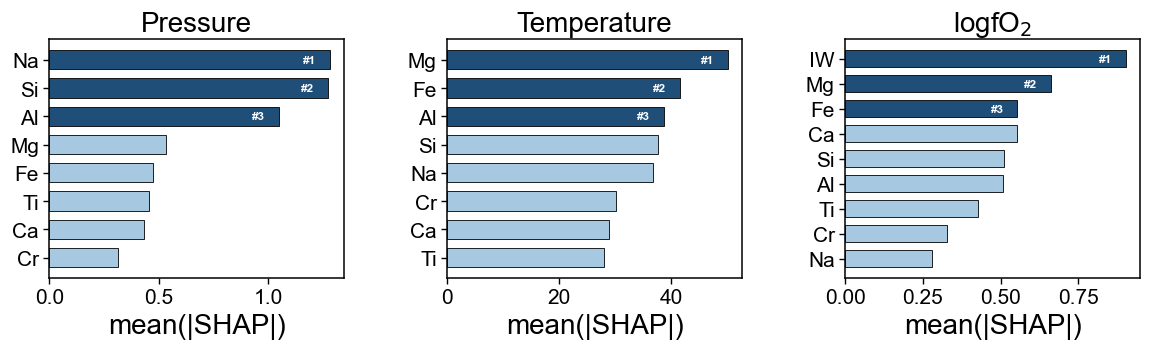

In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================================
# Style
# ==========================================================
set_sa_style()

# ==========================================================
# Base path

# ==========================================================
BASE_DIR = os.getcwd()
SHAP_BASE = os.path.join(BASE_DIR, "results", "SHAP_results")

print("Current working directory:", BASE_DIR)
print("SHAP base directory:", SHAP_BASE)


# ==========================================================
split_by_lithology = False

# ==========================================================
# Features
# ==========================================================
features_dict = {
    "Pressure": [
        "Si_Grt", "Ti_Grt", "Al_Grt", "Cr_Grt", "Fe_Grt",
        "Mg_Grt", "Ca_Grt", "Na_Grt"
    ],
    "Temperature": [
        "Si_Grt", "Ti_Grt", "Al_Grt", "Cr_Grt", "Fe_Grt",
        "Mg_Grt", "Ca_Grt", "Na_Grt"
    ],
    "logfO2": [
        "Si_Grt", "Ti_Grt", "Al_Grt", "Cr_Grt", "Fe_Grt",
        "Mg_Grt", "Ca_Grt", "Na_Grt", "IW_full"
    ]
}

target_dir_map = {
    "Pressure": "P",
    "Temperature": "T",
    "logfO2": "fO2"
}

# ==========================================================
# Read dependence_raw.xlsx from Peridotite and Eclogite
# Output columns:
#   feature value columns: Si_Grt, ...
#   feature shap columns:  Si_Grt_shap, ...
#   cluster_label
# ==========================================================
def load_dependence_raw(target_name, features):
    folder_name = target_dir_map[target_name]
    target_path = os.path.join(SHAP_BASE, folder_name)

    rock_config = {
        "Peridotitic": 1,
        "Basaltic": 2
    }

    dfs = []

    for rock_name, cluster_label in rock_config.items():
        file_path = os.path.join(target_path, rock_name, "dependence_raw.xlsx")

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"文件不存在: {file_path}")

        df_raw = pd.read_excel(file_path)

        out = pd.DataFrame()

        for feat in features:
            value_col = f"{feat}_value"
            shap_col = f"{feat}_shap"

            if value_col not in df_raw.columns:
                raise KeyError(f"{file_path} 中缺少列: {value_col}")
            if shap_col not in df_raw.columns:
                raise KeyError(f"{file_path} 中缺少列: {shap_col}")

            out[feat] = df_raw[value_col]
            out[f"{feat}_shap"] = df_raw[shap_col]

        out["cluster_label"] = cluster_label
        dfs.append(out)

    return pd.concat(dfs, ignore_index=True)

# ==========================================================
# Read all data
# ==========================================================
pressure = load_dependence_raw("Pressure", features_dict["Pressure"])
temperature = load_dependence_raw("Temperature", features_dict["Temperature"])
fo2 = load_dependence_raw("logfO2", features_dict["logfO2"])

models = {
    "Pressure": {
        "label": "Pressure",
        "df": pressure
    },
    "Temperature": {
        "label": "Temperature",
        "df": temperature
    },
    "logfO2": {
        "label": r"logfO$_2$",
        "df": fo2
    }
}

# ==========================================================
# SHAP importance
# use *_shap columns instead of raw feature columns
# ==========================================================
def shap_importance(df, features):
    shap_cols = [f"{f}_shap" for f in features]

    global_imp = df[shap_cols].abs().mean()
    global_imp.index = features

    peri = df[df["cluster_label"] == 1]
    basalt = df[df["cluster_label"] == 2]

    peri_imp = peri[shap_cols].abs().mean()
    peri_imp.index = features

    basalt_imp = basalt[shap_cols].abs().mean()
    basalt_imp.index = features

    return global_imp, peri_imp, basalt_imp

# ==========================================================
# Colors
# ==========================================================
base_color = "#A6C8E0"
highlight_color = "#1F4E79"

# ==========================================================
# Create figure
# split_by_lithology=True  -> 3x3
# split_by_lithology=False -> 1x3
# ==========================================================
if split_by_lithology:
    fig, axes = plt.subplots(3, 3, figsize=(11.6, 9.2))
    col_titles = ["Global", "Peridotitic", "Basaltic"]
else:
    fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.6))
    col_titles = ["Pressure", "Temperature", r"logfO$_2$"]

# ==========================================================
# Main loop
# ==========================================================
for i, (model_name, model_data) in enumerate(models.items()):
    df = model_data["df"]
    display_name = model_data["label"]
    features = features_dict[model_name]

    global_imp, peri_imp, basalt_imp = shap_importance(df, features)


    # ------------------------------------------------------
    if split_by_lithology:
        datasets = [global_imp, peri_imp, basalt_imp]
    else:
        datasets = [global_imp]

    for j, imp in enumerate(datasets):
        # --------------------------------------------------
        # 选择对应子图
        # split=True  -> axes[i, j]
        # split=False -> axes[i]
        # --------------------------------------------------
        if split_by_lithology:
            ax = axes[i, j]
        else:
            ax = axes[i]

        imp = imp.sort_values()

        labels = [
            "IW" if f == "IW_full" else f.replace("_Grt", "")
            for f in imp.index
        ]

        top3 = imp.sort_values(ascending=False).head(3).index
        colors = [
            highlight_color if f in top3 else base_color
            for f in imp.index
        ]

        ax.barh(
            labels,
            imp.values,
            color=colors,
            edgecolor="black",
            linewidth=0.6,
            height=0.68
        )

        x_max = imp.max()
        for rank, f in enumerate(top3):
            val = imp[f]
            y = imp.index.tolist().index(f)
            offset = x_max * 0.05 if x_max > 0 else 0.01

            ax.text(
                val - offset,
                y,
                f"#{rank + 1}",
                va="center",
                ha="right",
                color="white",
                fontsize=8.5,
                fontweight="bold"
            )


        # --------------------------------------------------
        if split_by_lithology:
            if i == 0:
                ax.set_title(col_titles[j], pad=6)

            if j == 0:
                ax.set_ylabel(display_name)
            else:
                ax.set_ylabel("")
        else:
            ax.set_title(display_name, pad=6)
            ax.set_ylabel("")

        ax.set_xlabel("mean(|SHAP|)")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.1)

        ax.tick_params(direction="out", width=1.0, length=4)
        ax.grid(False)

# ==========================================================
# Layout
# ==========================================================
plt.tight_layout()

if split_by_lithology:
    plt.subplots_adjust(wspace=0.28, hspace=0.28)
else:
    plt.subplots_adjust(wspace=0.35)

# ==========================================================
# Save figure
# ==========================================================
if split_by_lithology:
    out_png = "Fig2_SHAP_importance_3x3.png"
    out_pdf = "Fig2_SHAP_importance_3x3.pdf"
else:
    out_png = "Fig2_SHAP_importance_global_1x3.png"
    out_pdf = "Fig2_SHAP_importance_global_1x3.pdf"

plt.savefig(
    os.path.join(IMAGE_PATH, out_png),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(IMAGE_PATH, out_pdf),
    bbox_inches="tight"
)

plt.show()

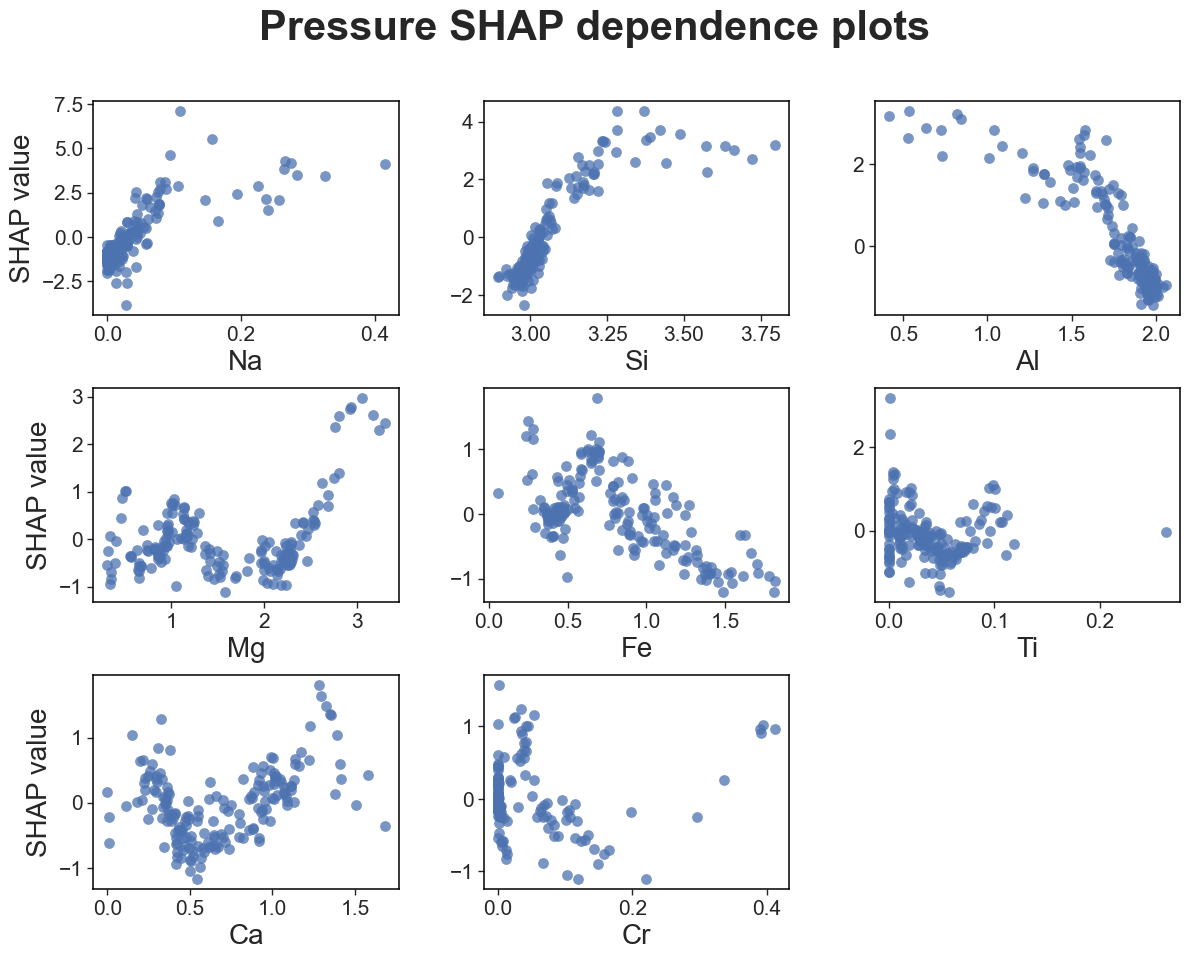

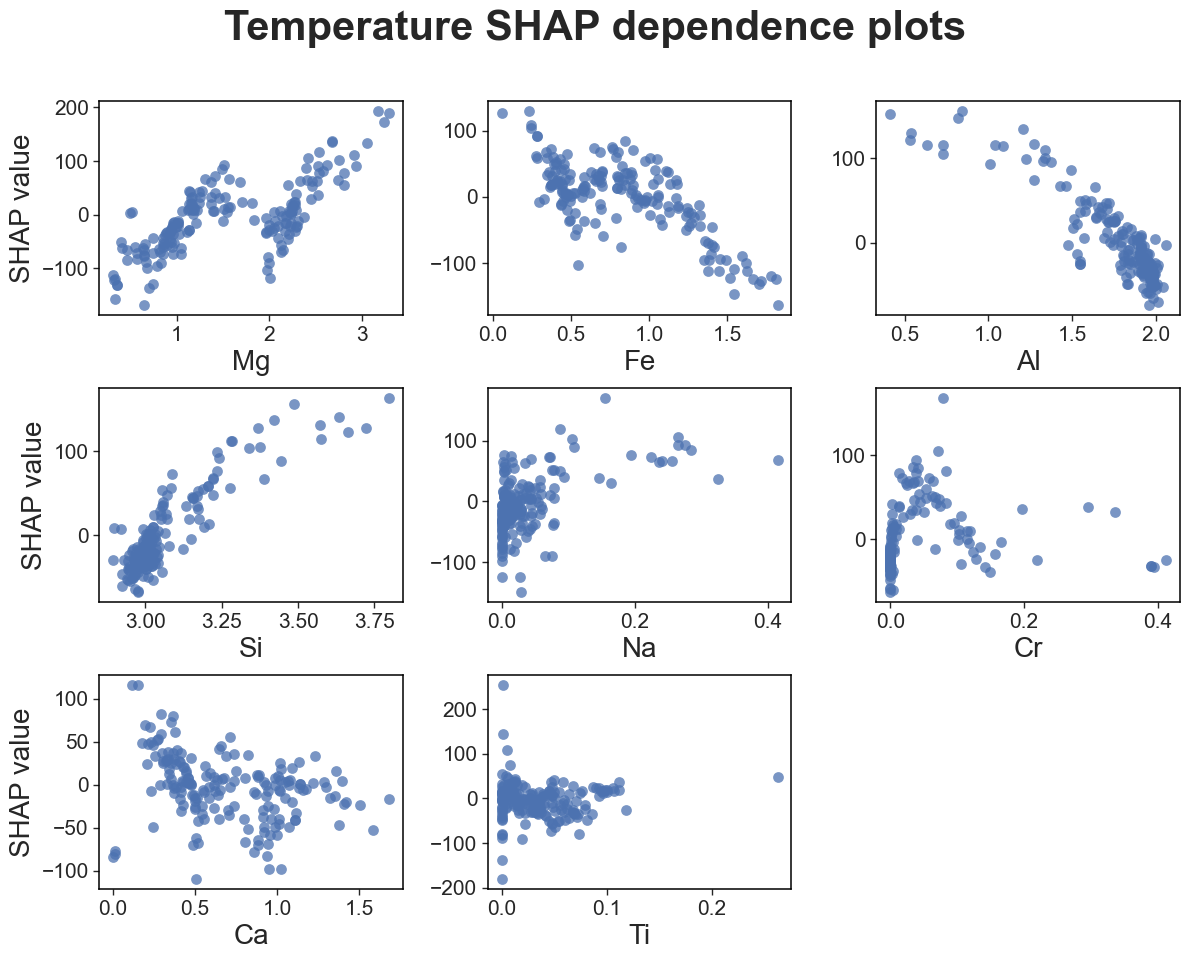

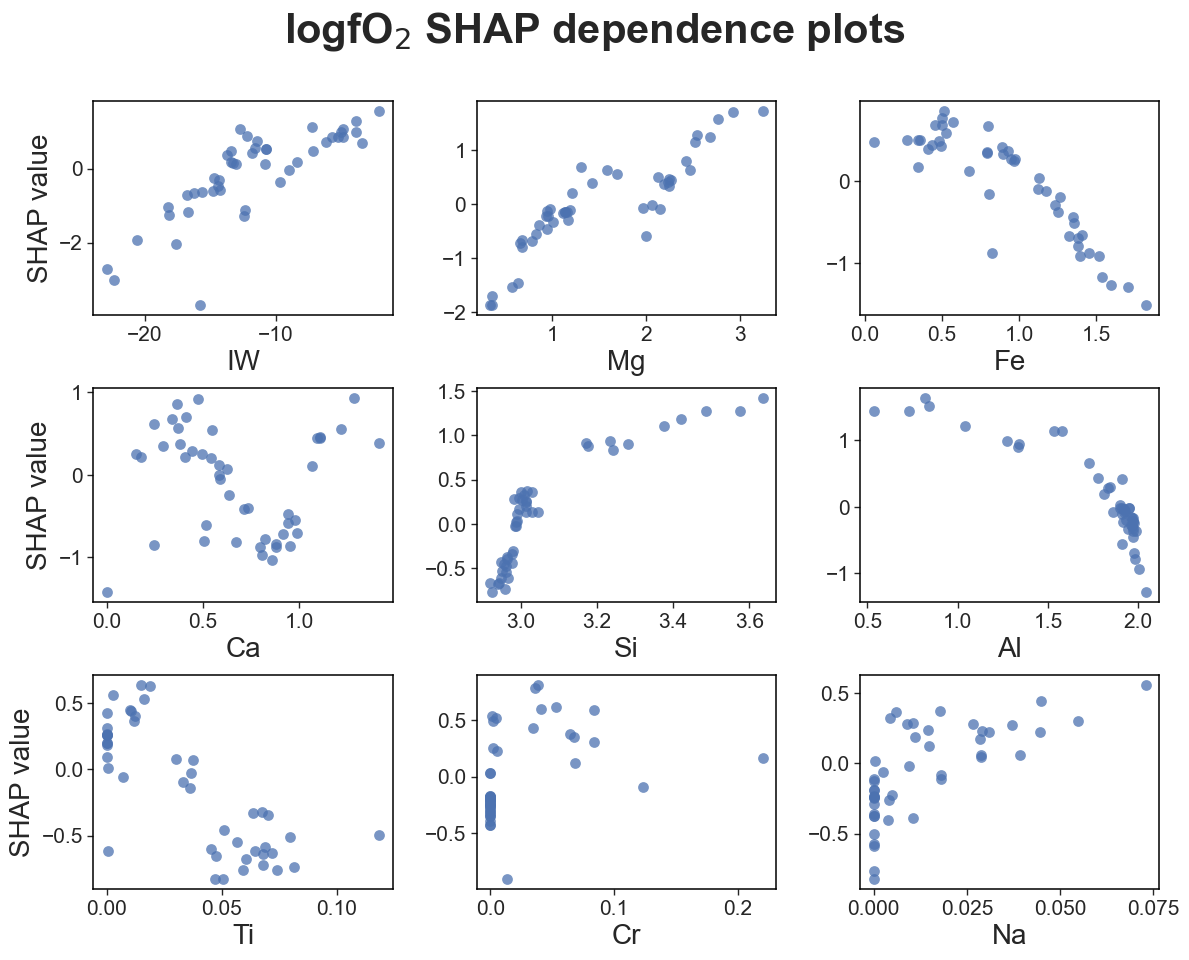

In [46]:
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Style
# ==========================================================
sns.set_style("white")
set_sa_style()


split_by_lithology = False

# ==========================================================
# Model info
# ==========================================================
models = {
    "Pressure": {
        "label": "Pressure",
        "df": pressure
    },
    "Temperature": {
        "label": "Temperature",
        "df": temperature
    },
    "logfO2": {
        "label": r"logfO$_2$",
        "df": fo2
    }
}

# ==========================================================
# Features
# ==========================================================
features_dict = {
    "Pressure": [
        "Si_Grt", "Ti_Grt", "Al_Grt", "Cr_Grt", "Fe_Grt",
        "Mg_Grt", "Ca_Grt", "Na_Grt"
    ],
    "Temperature": [
        "Si_Grt", "Ti_Grt", "Al_Grt", "Cr_Grt", "Fe_Grt",
        "Mg_Grt", "Ca_Grt", "Na_Grt"
    ],
    "logfO2": [
        "Si_Grt", "Ti_Grt", "Al_Grt", "Cr_Grt", "Fe_Grt",
        "Mg_Grt", "Ca_Grt", "Na_Grt", "IW_full"
    ]
}

# ==========================================================
# Lithology
# ==========================================================
lith_map = {
    1: "Peridotitic",
    2: "Basaltic"
}

palette = {
    "Peridotitic": "#3D5A80",
    "Basaltic": "#D08C60"
}


single_color = "#4C72B0"

# ==========================================================
# Helper
# ==========================================================
def beautify_axis(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.1)

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=4,
        width=1.0,
        bottom=True,
        top=False,
        left=True,
        right=False
    )

    ax.grid(False)

# ==========================================================
# SHAP importance
# ==========================================================
def shap_importance(df, features):
    shap_cols = [f"{f}_shap" for f in features]
    imp = df[shap_cols].abs().mean()
    imp.index = features
    return imp

# ==========================================================
# Plot dependence plots
# ==========================================================
for model_name, model_data in models.items():

    df = model_data["df"].copy()
    display_name = model_data["label"]


    if split_by_lithology:
        df["Lithology"] = df["cluster_label"].map(lith_map)

    features = features_dict[model_name]

    imp = shap_importance(df, features).sort_values(ascending=False)
    features_sorted = imp.index.tolist()

    n_features = len(features_sorted)
    ncols = 3
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.0 * ncols, 3.2 * nrows)
    )
    axes = axes.flatten()

    legend_handles = None
    legend_labels = None

    for i, f in enumerate(features_sorted):
        ax = axes[i]

        xcol = f
        ycol = f + "_shap"

        if xcol not in df.columns or ycol not in df.columns:
            ax.set_visible(False)
            continue


        # --------------------------------------------------
        if split_by_lithology:
            sns.scatterplot(
                data=df,
                x=xcol,
                y=ycol,
                hue="Lithology",
                hue_order=["Peridotitic", "Basaltic"],
                palette=palette,
                s=60,
                alpha=0.75,
                edgecolor=None,
                linewidth=0,
                ax=ax
            )

            if i == 0:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            if ax.get_legend() is not None:
                ax.get_legend().remove()

        else:
            sns.scatterplot(
                data=df,
                x=xcol,
                y=ycol,
                color=single_color,
                s=60,
                alpha=0.75,
                edgecolor=None,
                linewidth=0,
                ax=ax
            )

            if ax.get_legend() is not None:
                ax.get_legend().remove()

        feature_label = "IW" if f == "IW_full" else f.replace("_Grt", "")
        ax.set_xlabel(feature_label)

        if i % ncols == 0:
            ax.set_ylabel("SHAP value")
        else:
            ax.set_ylabel("")

        beautify_axis(ax)

    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"{display_name} SHAP dependence plots",
        y=0.995,
        fontsize=30,
        fontweight="bold"
    )


    if split_by_lithology and legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.95),
            prop={"size": 18}
        )

    plt.tight_layout()


    if split_by_lithology:
        plt.subplots_adjust(top=0.88, hspace=0.34, wspace=0.28)
    else:
        plt.subplots_adjust(top=0.90, hspace=0.34, wspace=0.28)


    if split_by_lithology:
        out_png = f"{model_name}_SHAP_dependence_all_features.png"
        out_pdf = f"{model_name}_SHAP_dependence_all_features.pdf"
    else:
        out_png = f"{model_name}_SHAP_dependence_all_features_global.png"
        out_pdf = f"{model_name}_SHAP_dependence_all_features_global.pdf"

    plt.savefig(
        os.path.join(IMAGE_PATH, out_png),
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        os.path.join(IMAGE_PATH, out_pdf),
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
# ----------------------------------------------------------
# CPU control
# ----------------------------------------------------------
MAX_CPU = 8

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"


def run_grid_search(
    target,
    model_type,
    train_df,
    BASE_FEATURES,
    LITHOLOGY_COLUMN,
    RANDOM_STATE,
    calculate_iw=None,
    best_P_params=None,
    best_T_params=None,
    n_splits=5,
):
    """
    target: "P" / "T" / "fO2"
    model_type: "xgboost" / "rf"
    """
    print("\n======================================")
    print(f"Grid Search | Target: {target} | Model: {model_type}")
    print("======================================")

    df = train_df.copy()
    stratify_labels = df[LITHOLOGY_COLUMN]

    # ------------------------------------------------------
    # Feature preparation
    # ------------------------------------------------------
    if target == "fO2":
        if best_P_params is None or best_T_params is None:
            raise ValueError(
                "For fO2 tuning you must provide best_P_params and best_T_params"
            )

        print("Generating IW_oof...")

        X_base = df[BASE_FEATURES].values
        P_oof = np.zeros(len(df))
        T_oof = np.zeros(len(df))

        skf_oof = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        for tr, val in skf_oof.split(X_base, stratify_labels):
            if model_type == "xgboost":
                P_model = XGBRegressor(
                    objective="reg:squarederror",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    **best_P_params,
                )
                T_model = XGBRegressor(
                    objective="reg:squarederror",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    **best_T_params,
                )
            else:
                P_model = RandomForestRegressor(
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    **best_P_params,
                )
                T_model = RandomForestRegressor(
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    **best_T_params,
                )

            P_model.fit(X_base[tr], df["P"].values[tr])
            T_model.fit(X_base[tr], df["T"].values[tr])

            P_oof[val] = P_model.predict(X_base[val])
            T_oof[val] = T_model.predict(X_base[val])

        df["IW_oof"] = calculate_iw(P_oof, T_oof)

        X = df[BASE_FEATURES + ["IW_oof"]]
        y = df["fO2"]

    else:
        X = df[BASE_FEATURES]
        y = df[target]

    # ------------------------------------------------------
    # Model selection
    # ------------------------------------------------------
    if model_type == "xgboost":
        model = XGBRegressor(
            random_state=RANDOM_STATE,
            tree_method="hist",
            objective="reg:squarederror",
            n_jobs=1,
        )

        param_grid_P = {
            "n_estimators": [3000],
            "min_child_weight": [2],
            "max_depth": [8],
            "learning_rate": [0.01],
            "subsample": [0.5],
            "colsample_bytree": [0.9],
            "gamma": [0],
        }

        param_grid_T = {
            "n_estimators": [3000],
            "min_child_weight": [3],
            "max_depth": [14],
            "learning_rate": [0.01],
            "subsample": [0.5],
            "colsample_bytree": [1],
            "gamma": [0.2],
        }

        param_grid_fO2 = {
            "n_estimators": [2000],
            "min_child_weight": [4],
            "max_depth": [6],
            "learning_rate": [0.05],
            "subsample": [0.9],
            "colsample_bytree": [0.6],
            "gamma": [0.2],
        }

    elif model_type == "rf":
        model = RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
        )

        param_grid_P = {
            "n_estimators": [400],
            "max_depth": [15],
            "min_samples_split": [2],
            "min_samples_leaf": [1],
            "max_features": [0.6],
        }

        param_grid_T = {
            "n_estimators": [2000],
            "max_depth": [23],
            "min_samples_split": [2],
            "min_samples_leaf": [1],
            "max_features": [0.6],
        }

        param_grid_fO2 = {
            "n_estimators": [1500],
            "max_depth": [13],
            "min_samples_split": [2],
            "min_samples_leaf": [1],
            "max_features": [0.8],
        }

    else:
        raise ValueError("model_type must be 'xgboost' or 'rf'")

    if target == "P":
        param_grid = param_grid_P
    elif target == "T":
        param_grid = param_grid_T
    else:
        param_grid = param_grid_fO2

    # ------------------------------------------------------
    # Print computation size
    # ------------------------------------------------------
    total_candidates = 1
    for v in param_grid.values():
        total_candidates *= len(v)

    total_fits = total_candidates * n_splits

    print(f"\nParameter combinations: {total_candidates}")
    print(f"CV folds: {n_splits}")
    print(f"Total fits: {total_fits}")
    print(f"CPU used: {MAX_CPU}")

    # ------------------------------------------------------
    # Grid search
    # ------------------------------------------------------
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    cv_splits = list(skf.split(X, stratify_labels))

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_splits,
        scoring="r2",
        n_jobs=MAX_CPU,
        verbose=2,
    )

    grid.fit(X, y)

    print("\nBest Parameters:")
    print(grid.best_params_)

    print("\nBest CV R2:")
    print(grid.best_score_)

    best_model = grid.best_estimator_
    return best_model, grid.best_params_, grid.best_score_

In [ ]:
P_model, best_P_params, score_P = run_grid_search(
    target="P",
    model_type="rf",  # "xgboost"
    train_df=pd.concat([df_P_T_train, df_fO2_train], ignore_index=True),
    BASE_FEATURES=BASE_FEATURES,
    LITHOLOGY_COLUMN=LITHOLOGY_COLUMN,
    RANDOM_STATE=RANDOM_STATE,
)

In [ ]:
T_model, best_T_params, score_T = run_grid_search(
    target="T",
    model_type="rf",
    train_df=pd.concat([df_P_T_train, df_fO2_train], ignore_index=True),
    BASE_FEATURES=BASE_FEATURES,
    LITHOLOGY_COLUMN=LITHOLOGY_COLUMN,
    RANDOM_STATE=RANDOM_STATE,
)

In [ ]:
fO2_model, best_fO2_params, score_fO2 = run_grid_search(
    target="fO2",
    model_type="rf",
    train_df=df_fO2_train,
    BASE_FEATURES=BASE_FEATURES,
    LITHOLOGY_COLUMN=LITHOLOGY_COLUMN,
    RANDOM_STATE=RANDOM_STATE,
    calculate_iw=calculate_iw,
    best_P_params=best_P_params,
    best_T_params=best_T_params,
)